# Classificando a Qualidade de Vinhos com Machine Learning



O objetivo deste projeto é analisar se as características físico-químicas dos vinhos podem ajudar a identificar sua qualidade. Para a análise, foi utilizado o Wine Quality Dataset, disponível no Kaggle.

Como a base já possui a avaliação de qualidade dos vinhos, foi adotado o Aprendizado Supervisionado. A variável quality foi transformada em quality_label, separando os vinhos em duas classes: alta qualidade e baixa ou média qualidade. Assim, o estudo foi desenvolvido como um problema de classificação binária.

A análise considera os dados históricos disponíveis e está direcionada ao desenvolvimento, treinamento e avaliação dos modelos.

### Objetivo

Avaliar se as **características físico-químicas dos vinhos** permitem prever sua classificação de qualidade por meio de técnicas de **Aprendizado Supervisionado**.

Para isso, a variável **`quality`** foi transformada em **`quality_label`**, considerando:

* **Alta qualidade (1):** `quality ≥ 7`
* **Baixa/Média qualidade (0):** `quality < 7`


## 2. Importação das Bibliotecas

Nesta seção são importadas as bibliotecas usadas na análise dos dados, nos gráficos e na construção dos modelos.


In [2]:
# 2. Importação das Bibliotecas

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Caminhos e Diretórios

from pathlib import Path


In [4]:
# Machine Learning - Preparação, Validação e Otimização

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)


In [5]:
# Machine Learning - Padronização

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay,
    classification_report
)


### 2.1 Configuração Visual dos Gráficos

Aqui ficam as cores, parâmetros visuais e nomes em português usados ao longo do notebook. A ideia é manter os gráficos com o mesmo padrão sem repetir configurações em cada célula.


In [6]:
# 2.1 Configuração Visual dos Gráficos

CORES = {
    "principal": "#2F5D8C",
    "secundaria": "#7FA6C9",
    "contexto": "#C7CDD4",
    "destaque": "#4E7D5A",
    "texto": "#333333",
    "fundo": "#F8F9FA"
}

COR_HISTOGRAMA = "#4776A8"
COR_BOXPLOT = "#4776A8"

PALETA_BARRAS = [
    "#ABC7E0",
    "#759FC5",
    "#4776A8",
    "#56549A",
    "#673A8E",
    "#54206F"
]

CMAP_CONTINUO = "cividis"
CMAP_CONTINUO_ALTERNATIVO = "viridis"

CMAP_CORRELACAO = "coolwarm"

PALETA_CATEGORICA = [
    "#0072B2",  # Azul
    "#E69F00",  # Laranja
    "#009E73",  # Verde
    "#CC79A7",  # Roxo rosado
    "#56B4E9",  # Azul claro
    "#D55E00",  # Vermelho alaranjado
    "#F0E442",  # Amarelo
    "#000000"   # Preto
]

COR_KDE = "#54206F"
COR_MEDIA = "#D55E00"
COR_MEDIANA = "#0072B2"

ALPHA_HISTOGRAMA = 0.85
ESPESSURA_KDE = 2.5

NOMES_VARIAVEIS = {
    "fixed acidity": "Acidez fixa",
    "volatile acidity": "Acidez volátil",
    "citric acid": "Ácido cítrico",
    "residual sugar": "Açúcar residual",
    "chlorides": "Cloretos",
    "free sulfur dioxide": "Dióxido de enxofre livre",
    "total sulfur dioxide": "Dióxido de enxofre total",
    "density": "Densidade",
    "pH": "pH",
    "sulphates": "Sulfatos",
    "alcohol": "Teor alcoólico",
    "quality": "Qualidade"
}


### 2.2 Funções Auxiliares para Visualização

As funções desta seção concentram ajustes que se repetem nos gráficos, como formatação, percentuais e salvamento das figuras.


In [7]:

# Adição de Percentuais Em Gráficos de Barras

def adicionar_percentual(ax, total):
    """
    Adiciona o percentual acima de cada barra do gráfico.

    Parâmetros
    ----------
    ax : matplotlib.axes.Axes
        Eixo onde o gráfico foi construído.
    total : int
        Total de observações utilizado no cálculo.
    """

    for barra in ax.patches:
        altura = barra.get_height()
        percentual = altura / total * 100

        ax.annotate(
            f"{percentual:.1f}%",
            (barra.get_x() + barra.get_width() / 2, altura),
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
            color=CORES["texto"]
        )

SALVAR_GRAFICOS = False
PASTA_GRAFICOS = "graficos"
DPI = 300

def salvar_grafico(nome_arquivo):
    """
    Salva o gráfico em formato PNG quando essa opção está habilitada.
    """

    if SALVAR_GRAFICOS:
        Path(PASTA_GRAFICOS).mkdir(
            parents=True,
            exist_ok=True
        )

        plt.savefig(
            f"{PASTA_GRAFICOS}/{nome_arquivo}.png",
            dpi=DPI,
            bbox_inches="tight"
        )

def grafico_format(titulo, xlabel="", ylabel="", legenda=False):
    """
    Aplica a formatação visual padrão aos gráficos.
    """

    plt.title(
        titulo,
        fontsize=14,
        fontweight="bold",
        color=CORES["texto"]
    )

    plt.xlabel(
        xlabel,
        fontsize=11,
        color=CORES["texto"]
    )

    plt.ylabel(
        ylabel,
        fontsize=11,
        color=CORES["texto"]
    )

    plt.grid(
        axis="y",
        linestyle=":",
        alpha=0.20
    )

    if legenda:
        plt.legend()

    plt.tight_layout()


### 2.3 Classe para Análise de Distribuição

A classe `AnalisadorDistribuicao` reúne os recursos usados na análise das variáveis numéricas: histograma, KDE, média, mediana, assimetria e curtose.


In [8]:
# 2.3 Classe para Análise de Distribuição

class AnalisadorDistribuicao:
    """
    Analisa e representa graficamente a distribuição
    das variáveis numéricas.
    """

    def __init__(
        self,
        cor_histograma,
        cor_kde,
        cor_media,
        cor_mediana,
        alpha_histograma=0.85,
        espessura_kde=2.5,
        bins=30
    ):
        self.cor_histograma = cor_histograma
        self.cor_kde = cor_kde
        self.cor_media = cor_media
        self.cor_mediana = cor_mediana
        self.alpha_histograma = alpha_histograma
        self.espessura_kde = espessura_kde
        self.bins = bins

    def classificar_assimetria(self, assimetria):
        """Classifica a distribuição com base na assimetria."""

        intensidade = abs(assimetria)

        if intensidade < 0.50:
            return "Aproximadamente simétrica"

        if 0.50 <= assimetria < 1:
            return "Assimétrica à direita — intensidade moderada"

        if assimetria >= 1:
            return "Assimétrica à direita — intensidade elevada"

        if -1 < assimetria <= -0.50:
            return "Assimétrica à esquerda — intensidade moderada"

        return "Assimétrica à esquerda — intensidade elevada"

    def classificar_curtose(self, curtose):
        """Classifica a distribuição com base na curtose de Fisher."""

        if abs(curtose) < 0.50:
            return "Mesocúrtica"

        if curtose > 0:
            return "Leptocúrtica — caudas mais pesadas"

        return "Platicúrtica — caudas mais leves"

    def gerar_tabela_resumo(
        self,
        df,
        colunas,
        nomes_variaveis=None
    ):
        """
        Gera uma tabela com média, mediana, assimetria,
        curtose e suas classificações.
        """

        resultados = []

        for coluna in colunas:

            if coluna not in df.columns:
                print(
                    f"A variável '{coluna}' não foi encontrada "
                    "no DataFrame e será ignorada."
                )
                continue

            dados = df[coluna].dropna()

            if dados.empty:
                print(
                    f"A variável '{coluna}' não possui valores "
                    "válidos e será ignorada."
                )
                continue

            media = dados.mean()
            mediana = dados.median()
            assimetria = dados.skew()
            curtose = dados.kurt()

            nome_exibicao = (
                nomes_variaveis.get(coluna, coluna)
                if nomes_variaveis is not None
                else coluna
            )

            resultados.append({
                "Variável": nome_exibicao,
                "Média": media,
                "Mediana": mediana,
                "Assimetria": assimetria,
                "Classificação da Assimetria":
                    self.classificar_assimetria(assimetria),
                "Curtose": curtose,
                "Classificação da Curtose":
                    self.classificar_curtose(curtose)
            })

        tabela_resumo = pd.DataFrame(resultados)

        if tabela_resumo.empty:
            return tabela_resumo

        colunas_numericas = [
            "Média",
            "Mediana",
            "Assimetria",
            "Curtose"
        ]

        tabela_resumo[colunas_numericas] = (
            tabela_resumo[colunas_numericas].round(2)
        )

        return tabela_resumo

    def plotar_histograma(self, df, coluna, nome):
        """
        Gera o histograma e apresenta um resumo
        da distribuição da variável.
        """

        if coluna not in df.columns:
            print(
                f"A variável '{coluna}' não foi encontrada no DataFrame."
            )
            return

        dados = df[coluna].dropna()

        if dados.empty:
            print(
                f"A variável {nome} não possui valores disponíveis."
            )
            return

        media = dados.mean()
        mediana = dados.median()
        assimetria = dados.skew()
        curtose = dados.kurt()

        classificacao_assimetria = (
            self.classificar_assimetria(assimetria)
        )

        classificacao_curtose = (
            self.classificar_curtose(curtose)
        )

        figura, ax = plt.subplots(figsize=(9, 5))

        sns.histplot(
            data=dados,
            bins=self.bins,
            stat="count",
            kde=True,
            ax=ax,
            color=self.cor_histograma,
            alpha=self.alpha_histograma,
            edgecolor="white",
            linewidth=0.40
        )

        if len(ax.lines) > 0:
            linha_kde = ax.lines[-1]

            linha_kde.set_color(self.cor_kde)
            linha_kde.set_linewidth(self.espessura_kde)
            linha_kde.set_label("Curva KDE")

        ax.axvline(
            x=media,
            color=self.cor_media,
            linestyle="--",
            linewidth=2,
            label=f"Média: {media:.2f}".replace(".", ",")
        )

        ax.axvline(
            x=mediana,
            color=self.cor_mediana,
            linestyle=":",
            linewidth=2.5,
            label=f"Mediana: {mediana:.2f}".replace(".", ",")
        )

        ax.set_axisbelow(True)

        grafico_format(
            titulo=f"Distribuição — {nome}",
            xlabel=nome,
            ylabel="Frequência",
            legenda=True
        )

        salvar_grafico(
            f"histograma_{coluna}"
        )

        plt.show()

        print(f"Análise da variável: {nome}")
        print("-" * 60)

        print(f"Média: {media:.4f}")
        print(f"Mediana: {mediana:.4f}")

        print(
            f"Assimetria: {assimetria:.4f} — "
            f"{classificacao_assimetria}"
        )

        print(
            f"Curtose: {curtose:.4f} — "
            f"{classificacao_curtose}"
        )

        print(
            "Observação: a curva KDE auxilia na visualização "
            "do formato da distribuição."
        )

        print("=" * 60)
        print()


### 2.4 Funções Auxiliares para Análises Estatísticas

Nesta seção são definidas as funções usadas para calcular e visualizar a correlação entre as variáveis.


In [9]:
# 2.4 Funções Auxiliares para Análises Estatísticas

def calcular_matriz_correlacao(df):
    """
    Calcula a matriz de correlação de Pearson entre
    as variáveis numéricas selecionadas.
    """

    dados_correlacao = df.copy()

    dados_correlacao = dados_correlacao.drop(
        columns=["Id", "quality_label"],
        errors="ignore"
    )

    # Seleciona apenas as variáveis numéricas
    dados_numericos = dados_correlacao.select_dtypes(
        include="number"
    )

    matriz_correlacao = dados_numericos.corr(
        method="pearson"
    )

    return matriz_correlacao

def plotar_matriz_correlacao(matriz):
    """
    Exibe a matriz de correlação em formato de mapa de calor.
    """

    matriz_exibicao = matriz.rename(
        index=NOMES_VARIAVEIS,
        columns=NOMES_VARIAVEIS
    )

    plt.figure(figsize=(13, 9))

    sns.heatmap(
        matriz_exibicao,
        annot=True,
        fmt=".2f",
        cmap=CMAP_CORRELACAO,
        center=0,
        vmin=-1,
        vmax=1,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={
            "label": "Coeficiente de correlação"
        }
    )

    plt.title(
        "Matriz de Correlação das Variáveis",
        fontsize=14,
        fontweight="bold",
        color=CORES["texto"]
    )

    plt.xlabel("")
    plt.ylabel("")

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.yticks(rotation=0)

    plt.tight_layout()

    salvar_grafico(
        "matriz_correlacao"
    )

    plt.show()


### 2.5 Funções Auxiliares para Modelagem

As funções desta seção são reutilizadas no treinamento e na avaliação dos modelos. Para a classe **Alta Qualidade (1)**, serão calculados `Precision`, `Recall` e `F1-Score`.


In [10]:
# 2.5 Funções Auxiliares para Modelagem

def treinar_e_prever_modelo(
    modelo,
    caracteristicas_treino_modelo,
    classe_treino_modelo,
    caracteristicas_teste_modelo
):
    """
    Treina o modelo e gera previsões para o conjunto de teste.
    """

    modelo.fit(
        caracteristicas_treino_modelo,
        classe_treino_modelo
    )

    previsoes = modelo.predict(
        caracteristicas_teste_modelo
    )

    return previsoes

def avaliar_classe_alta_qualidade(
    classe_real,
    previsoes,
    classe_positiva=1
):
    """
    Calcula Precision, Recall e F1-Score para a classe positiva.
    """

    return {
        "Precision": precision_score(
            classe_real,
            previsoes,
            pos_label=classe_positiva,
            zero_division=0
        ),
        "Recall": recall_score(
            classe_real,
            previsoes,
            pos_label=classe_positiva,
            zero_division=0
        ),
        "F1-Score": f1_score(
            classe_real,
            previsoes,
            pos_label=classe_positiva,
            zero_division=0
        )
    }


## 3. Carregamento dos Dados



In [11]:

# Caminho da base de dados
caminho_base = Path(
    r"C:\Users\erika\OneDrive\Documents\_Cursos\_DATA_ANALYTICS_FIAP\wine-quality-classification\data\WineQT.csv"
)

df = pd.read_csv(caminho_base)

df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## 4. Preparação dos Dados




### 4.1 Transformação da Variável-Alvo

A variável `quality` será utilizada para criar a variável-alvo **`quality_label`**, transformando o problema em uma **classificação binária**:

* **Alta qualidade (1):** `quality ≥ 7`
* **Baixa/Média qualidade (0):** `quality < 7`

A variável `quality` será mantida para as análises exploratórias, mas não será utilizada como variável preditora nos modelos.

In [12]:
# DISTRIBUIÇÃO DA VARIÁVEL ORIGINAL (quality)

display(
    df["quality"]
    .value_counts()
    .sort_index()
)


quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

In [13]:
# 4.1 Transformação da Variável Alvo

df["quality_label"] = (
    df["quality"] >= 7
).astype(int)

display(
    df[["quality", "quality_label"]].head()
)

distribuicao_classes = (
    df["quality_label"]
    .value_counts()
    .sort_index()
)

proporcao_classes = (
    df["quality_label"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

tabela_classes = pd.DataFrame({
    "Quantidade": distribuicao_classes,
    "Percentual (%)": proporcao_classes.round(2)
})

tabela_classes.index = [
    "Baixa/Média Qualidade",
    "Alta Qualidade"
]

display(tabela_classes)


,quality,quality_label
0,5,0
1,5,0
2,5,0
3,6,0
4,5,0


,Quantidade,Percentual (%)
Baixa/Média Qualidade,984,86.09
Alta Qualidade,159,13.91


### 4.2 Análise do Balanceamento das Classes

A variável `quality_label` apresentou **984 registros (86,09%)** de baixa/média qualidade e **159 registros (13,91%)** de alta qualidade, indicando desbalanceamento entre as classes.

Por isso, a avaliação dos modelos não será baseada apenas na acurácia. Também serão consideradas métricas como **Precision, Recall, F1-Score** e **matriz de confusão**.

Neste momento, não serão aplicadas técnicas de balanceamento. Essa necessidade será avaliada posteriormente, de acordo com o desempenho dos modelos.


C:\Users\erika\AppData\Local\Temp\ipykernel_27916\2277840507.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([


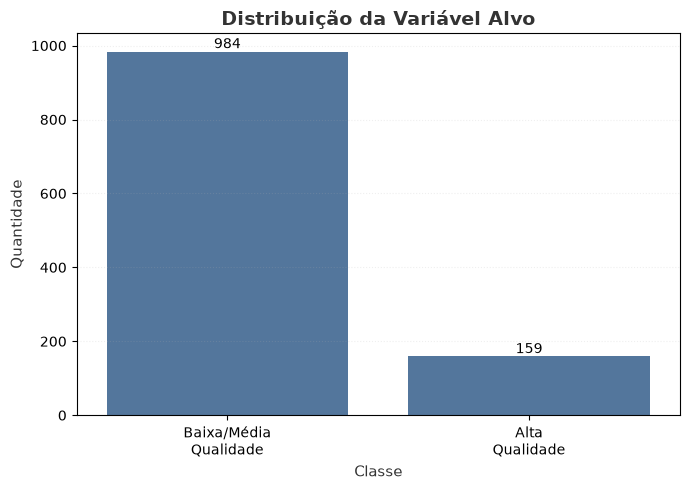

In [14]:
# Gráfico da Distribuição das Classes

plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="quality_label",
    color=COR_HISTOGRAMA
)

ax.set_xticklabels([
    "Baixa/Média\nQualidade",
    "Alta\nQualidade"
])

grafico_format(
    titulo="Distribuição da Variável Alvo",
    xlabel="Classe",
    ylabel="Quantidade",
    legenda=False
)

for barra in ax.patches:

    altura = barra.get_height()

    ax.annotate(
        f"{int(altura)}",
        (
            barra.get_x() + barra.get_width()/2,
            altura
        ),
        ha="center",
        va="bottom",
        fontsize=10
    )

salvar_grafico("distribuicao_variavel_alvo")

plt.show()


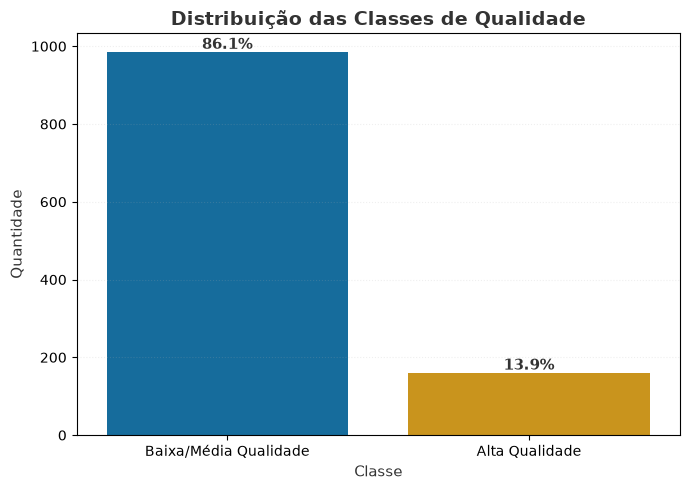

In [15]:
# Visualização da Distribuição da Variável Alvo

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="quality_label",
    hue="quality_label",
    palette=PALETA_CATEGORICA[:2],
    legend=False
)

ax.set_xticks([0, 1])
ax.set_xticklabels([
    "Baixa/Média Qualidade",
    "Alta Qualidade"
])

adicionar_percentual(
    ax,
    total=len(df)
)

grafico_format(
    titulo="Distribuição das Classes de Qualidade",
    xlabel="Classe",
    ylabel="Quantidade"
)

salvar_grafico(
    "distribuicao_quality_label"
)

plt.show()


In [16]:
# Confere a distribuição percentual
df["quality_label"].value_counts(normalize=True).mul(100).round(2)


quality_label
0    86.09
1    13.91
Name: proportion, dtype: float64

## 5. Conhecendo a Base de Dados




### 5.1 Dimensões da Base

Primeiro, são verificadas a quantidade de registros e a quantidade de variáveis da base.


In [17]:
# 5.1 Dimensões da Base

numero_registros, numero_variaveis = df.shape

print(f"Quantidade de registros: {numero_registros}")
print(f"Quantidade de variáveis: {numero_variaveis}")


Quantidade de registros: 1143
Quantidade de variáveis: 14


### 5.2 Estrutura da Base

A estrutura das colunas é verificada para identificar tipos de dados e quantidade de valores preenchidos.


In [18]:
# 5.2 Estrutura da Base

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
 13  quality_label         1143 non-null   int64  
dtypes: float64(11), int64(3)
memory usage: 125.1 KB


### 5.3 Verificação de Valores Ausentes

Nesta etapa é verificado se existem valores ausentes que exijam algum tratamento antes da modelagem.


In [19]:
# 5.3 Verificação de Valores Ausentes

valores_ausentes = df.isnull().sum()

display(
    valores_ausentes[valores_ausentes > 0]
)

print(f"Total de valores ausentes: {valores_ausentes.sum()}")


Series([], dtype: int64)

Total de valores ausentes: 0


### 5.4 Verificação de Registros Duplicados

A análise verifica duplicidades completas e também registros que repetem as mesmas informações quando o `Id` é desconsiderado.


In [20]:
# 5.4 Verificação de Registros Duplicados

registros_duplicados = df.duplicated().sum()

print(f"Quantidade de registros duplicados: {registros_duplicados}")


Quantidade de registros duplicados: 0


In [21]:
# Verifica duplicidades desconsiderando a variável identificadora
registros_duplicados_sem_id = (
    df.drop(columns=["Id"], errors="ignore")
    .duplicated()
    .sum()
)

print(
    "Quantidade de registros duplicados desconsiderando o Id: "
    f"{registros_duplicados_sem_id}"
)


Quantidade de registros duplicados desconsiderando o Id: 125


In [22]:
# Análise dos Registros Repetidos

colunas_analise = df.columns.drop("Id", errors="ignore")

registros_repetidos = df[
    df.duplicated(
        subset=colunas_analise,
        keep=False
    )
].sort_values(
    by=list(colunas_analise)
)

print(
    f"Total de registros envolvidos em repetições: "
    f"{len(registros_repetidos)}"
)

display(registros_repetidos)


Total de registros envolvidos em repetições: 239


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,quality_label
96,5.2,0.340,0.00,1.8,0.050,27.0,63.0,0.99160,3.68,0.79,14.0,6,142,0
98,5.2,0.340,0.00,1.8,0.050,27.0,63.0,0.99160,3.68,0.79,14.0,6,144,0
949,6.0,0.500,0.00,1.4,0.057,15.0,26.0,0.99448,3.36,0.45,9.5,5,1336,0
950,6.0,0.500,0.00,1.4,0.057,15.0,26.0,0.99448,3.36,0.45,9.5,5,1337,0
951,6.0,0.500,0.00,1.4,0.057,15.0,26.0,0.99448,3.36,0.45,9.5,5,1338,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,12.8,0.615,0.66,5.8,0.083,7.0,42.0,1.00220,3.07,0.73,10.0,7,366,1
400,13.0,0.470,0.49,4.3,0.085,6.0,47.0,1.00210,3.30,0.68,12.7,6,559,0
404,13.0,0.470,0.49,4.3,0.085,6.0,47.0,1.00210,3.30,0.68,12.7,6,564,0
170,15.0,0.210,0.44,2.2,0.075,10.0,24.0,1.00005,3.07,0.84,9.2,7,243,1


In [23]:
# Consistência dos Registros Repetidos

caracteristicas = [
    coluna for coluna in df.columns
    if coluna not in ["Id", "quality", "quality_label"]
]

notas_por_grupo = (
    df.groupby(caracteristicas)["quality"]
    .nunique()
)

grupos_notas_diferentes = notas_por_grupo[
    notas_por_grupo > 1
]

print(
    "Grupos com as mesmas características e notas diferentes: "
    f"{len(grupos_notas_diferentes)}"
)


Grupos com as mesmas características e notas diferentes: 0


### Resultado

Não foram encontrados registros totalmente duplicados. Quando o `Id` é desconsiderado, aparecem **125 registros com valores repetidos** nas demais variáveis.

Esses casos foram mantidos porque podem representar observações distintas com as mesmas medições físico-químicas.


### 5.5 Verificação de Valores Únicos

A quantidade de valores distintos por coluna ajuda a identificar variáveis com pouca variação.


In [24]:
# 5.5 Verificação de Valores Únicos

valores_unicos = df.nunique()

display(
    valores_unicos.to_frame(
        name="Quantidade de Valores Únicos"
    )
)


,Quantidade de Valores Únicos
fixed acidity,91
volatile acidity,135
citric acid,77
residual sugar,80
chlorides,131
free sulfur dioxide,53
total sulfur dioxide,138
density,388
pH,87
sulphates,89


In [25]:
# 5.5 Verificação de Valores Únicos

valores_unicos = df.nunique()

print(valores_unicos)


fixed acidity             91
volatile acidity         135
citric acid               77
residual sugar            80
chlorides                131
free sulfur dioxide       53
total sulfur dioxide     138
density                  388
pH                        87
sulphates                 89
alcohol                   61
quality                    6
Id                      1143
quality_label              2
dtype: int64


## 6. Estatística Descritiva




### 6.1 Resumo Estatístico

O resumo estatístico reúne medidas de posição e dispersão das variáveis numéricas, como média, desvio-padrão, quartis, mínimo e máximo.


In [26]:
# 6.1 Resumo Estatístico das Variáveis

colunas_analise = df.columns.drop(
    ["Id", "quality_label"],
    errors="ignore"
)

resumo_estatistico = (
    df[colunas_analise]
    .describe()
    .T
    .round(4)
)

display(resumo_estatistico)


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.3111,1.7476,4.6000,7.1000,7.9000,9.1000,15.9000
volatile acidity,1143.0,0.5313,0.1796,0.1200,0.3925,0.5200,0.6400,1.5800
citric acid,1143.0,0.2684,0.1967,0.0000,0.0900,0.2500,0.4200,1.0000
residual sugar,1143.0,2.5322,1.3559,0.9000,1.9000,2.2000,2.6000,15.5000
chlorides,1143.0,0.0869,0.0473,0.0120,0.0700,0.0790,0.0900,0.6110
free sulfur dioxide,1143.0,15.6155,10.2505,1.0000,7.0000,13.0000,21.0000,68.0000
total sulfur dioxide,1143.0,45.9147,32.7821,6.0000,21.0000,37.0000,61.0000,289.0000
density,1143.0,0.9967,0.0019,0.9901,0.9956,0.9967,0.9978,1.0037
pH,1143.0,3.3110,0.1567,2.7400,3.2050,3.3100,3.4000,4.0100
sulphates,1143.0,0.6577,0.1704,0.3300,0.5500,0.6200,0.7300,2.0000


In [27]:
# 6.2 Medidas de Dispersão

amplitude = (
    df[colunas_analise].max()
    - df[colunas_analise].min()
)

coeficiente_variacao = (
    df[colunas_analise].std()
    / df[colunas_analise].mean()
    * 100
)

tabela_dispersao = pd.DataFrame({
    "Amplitude": amplitude,
    "Coeficiente de Variação (%)": coeficiente_variacao
}).round(2)

display(tabela_dispersao)


,Amplitude,Coeficiente de Variação (%)
fixed acidity,11.30,21.03
volatile acidity,1.46,33.81
citric acid,1.00,73.29
residual sugar,14.60,53.55
chlorides,0.60,54.37
free sulfur dioxide,67.00,65.64
total sulfur dioxide,283.00,71.40
density,0.01,0.19
pH,1.27,4.73
sulphates,1.67,25.91


### Síntese

As variáveis apresentam escalas e amplitudes bem diferentes. Em algumas delas, os valores máximos estão distantes dos quartis superiores, o que indica a necessidade de observar a distribuição e possíveis valores extremos nas próximas etapas.


## 7. Análise Exploratória dos Dados




### 7.1 Distribuição das Variáveis

As distribuições das características físico-químicas são analisadas com histogramas e curvas KDE. Média, mediana, assimetria e curtose complementam a leitura dos gráficos.


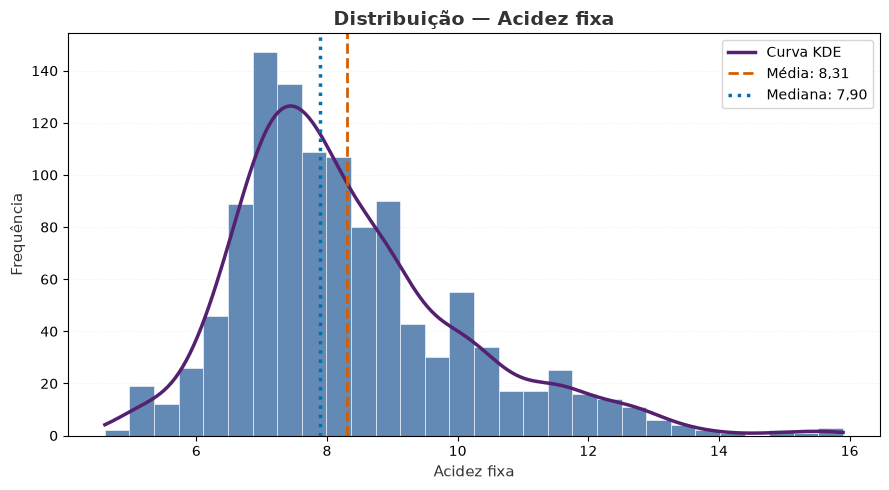

Análise da variável: Acidez fixa
------------------------------------------------------------
Média: 8.3111
Mediana: 7.9000
Assimetria: 1.0449 — Assimétrica à direita — intensidade elevada
Curtose: 1.3846 — Leptocúrtica — caudas mais pesadas
Observação: a curva KDE auxilia na visualização do formato da distribuição.



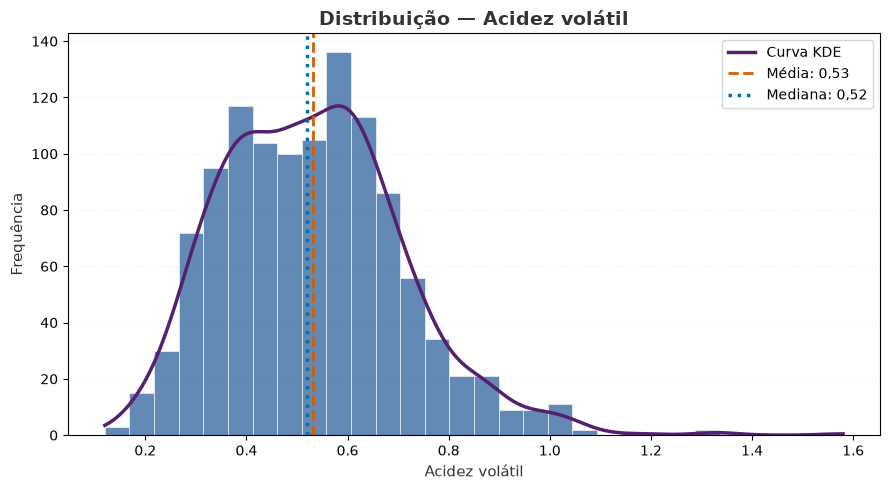

Análise da variável: Acidez volátil
------------------------------------------------------------
Média: 0.5313
Mediana: 0.5200
Assimetria: 0.6815 — Assimétrica à direita — intensidade moderada
Curtose: 1.3755 — Leptocúrtica — caudas mais pesadas
Observação: a curva KDE auxilia na visualização do formato da distribuição.



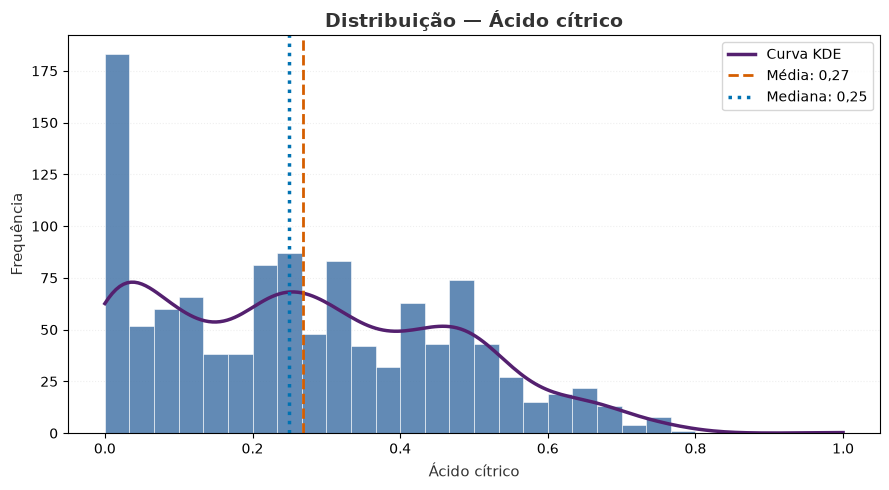

Análise da variável: Ácido cítrico
------------------------------------------------------------
Média: 0.2684
Mediana: 0.2500
Assimetria: 0.3716 — Aproximadamente simétrica
Curtose: -0.7147 — Platicúrtica — caudas mais leves
Observação: a curva KDE auxilia na visualização do formato da distribuição.



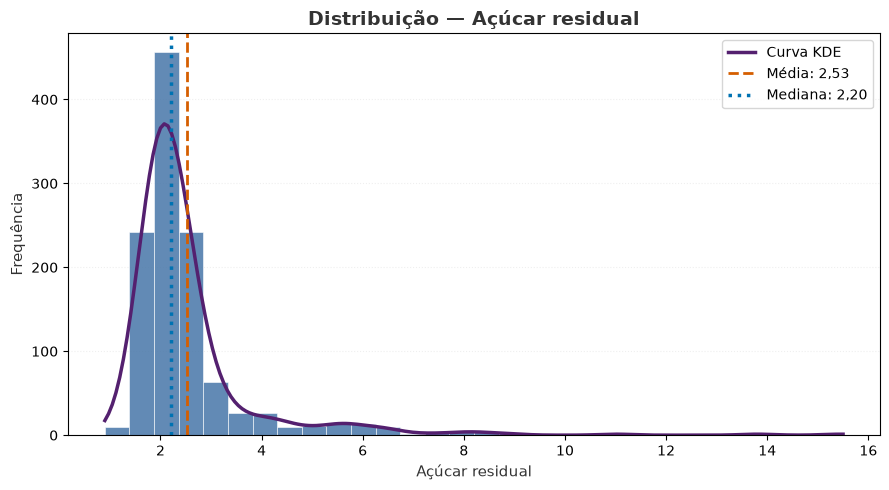

Análise da variável: Açúcar residual
------------------------------------------------------------
Média: 2.5322
Mediana: 2.2000
Assimetria: 4.3611 — Assimétrica à direita — intensidade elevada
Curtose: 27.6754 — Leptocúrtica — caudas mais pesadas
Observação: a curva KDE auxilia na visualização do formato da distribuição.



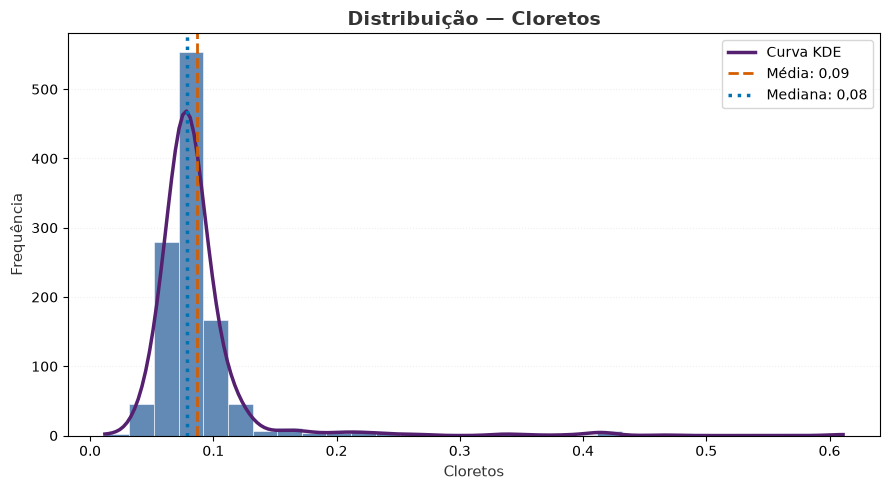

Análise da variável: Cloretos
------------------------------------------------------------
Média: 0.0869
Mediana: 0.0790
Assimetria: 6.0264 — Assimétrica à direita — intensidade elevada
Curtose: 47.0783 — Leptocúrtica — caudas mais pesadas
Observação: a curva KDE auxilia na visualização do formato da distribuição.



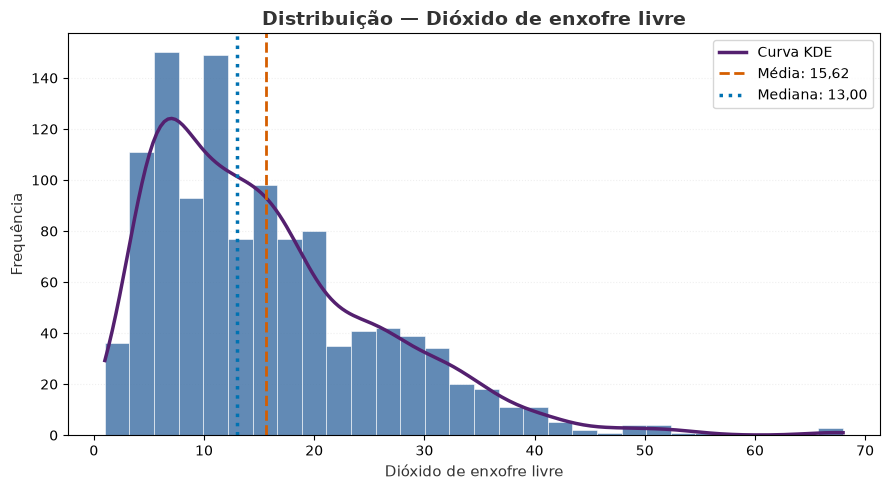

Análise da variável: Dióxido de enxofre livre
------------------------------------------------------------
Média: 15.6155
Mediana: 13.0000
Assimetria: 1.2313 — Assimétrica à direita — intensidade elevada
Curtose: 1.9322 — Leptocúrtica — caudas mais pesadas
Observação: a curva KDE auxilia na visualização do formato da distribuição.



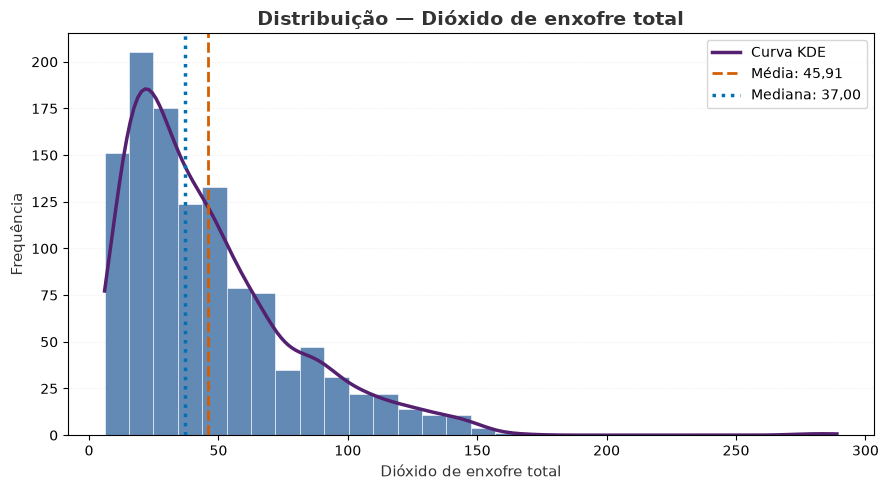

Análise da variável: Dióxido de enxofre total
------------------------------------------------------------
Média: 45.9147
Mediana: 37.0000
Assimetria: 1.6658 — Assimétrica à direita — intensidade elevada
Curtose: 5.0987 — Leptocúrtica — caudas mais pesadas
Observação: a curva KDE auxilia na visualização do formato da distribuição.



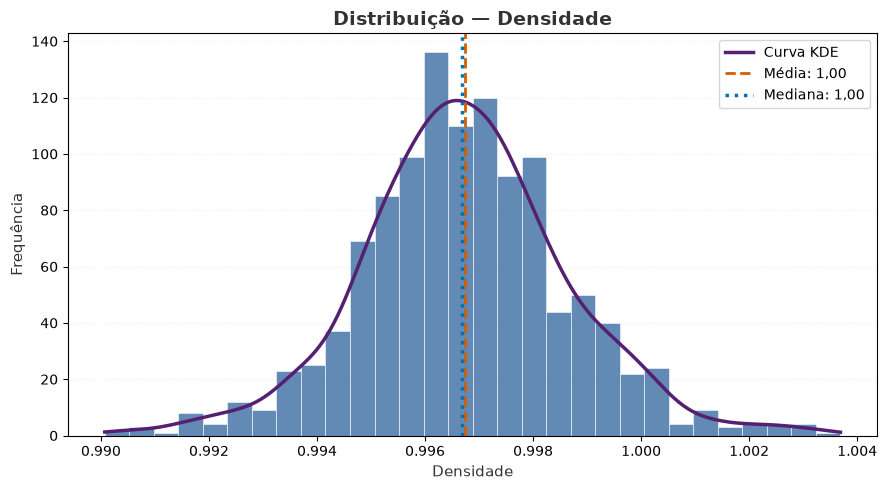

Análise da variável: Densidade
------------------------------------------------------------
Média: 0.9967
Mediana: 0.9967
Assimetria: 0.1024 — Aproximadamente simétrica
Curtose: 0.8881 — Leptocúrtica — caudas mais pesadas
Observação: a curva KDE auxilia na visualização do formato da distribuição.



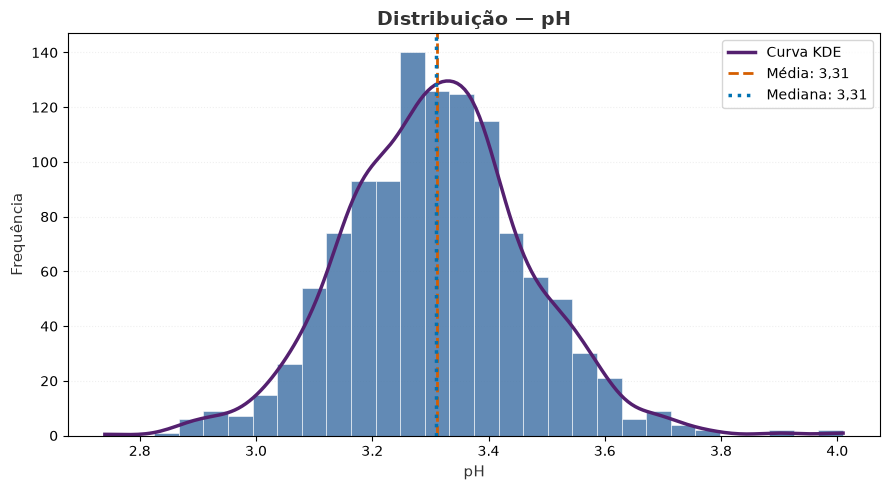

Análise da variável: pH
------------------------------------------------------------
Média: 3.3110
Mediana: 3.3100
Assimetria: 0.2211 — Aproximadamente simétrica
Curtose: 0.9258 — Leptocúrtica — caudas mais pesadas
Observação: a curva KDE auxilia na visualização do formato da distribuição.



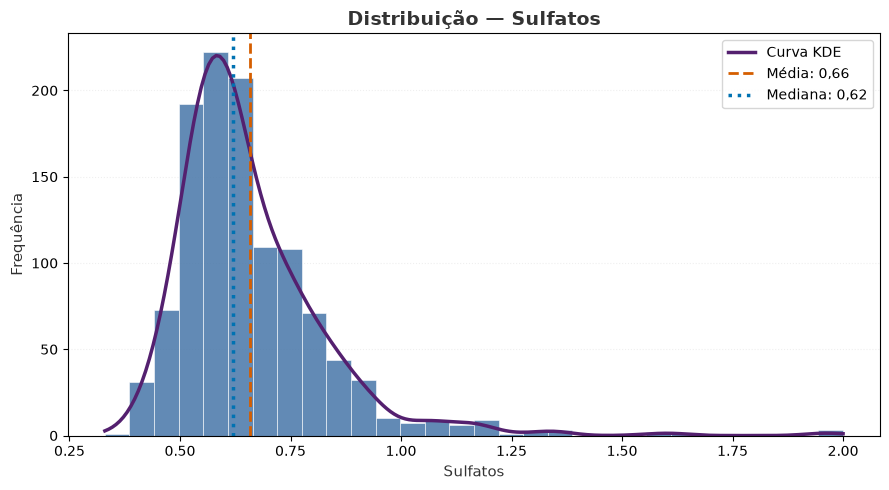

Análise da variável: Sulfatos
------------------------------------------------------------
Média: 0.6577
Mediana: 0.6200
Assimetria: 2.4973 — Assimétrica à direita — intensidade elevada
Curtose: 12.0174 — Leptocúrtica — caudas mais pesadas
Observação: a curva KDE auxilia na visualização do formato da distribuição.



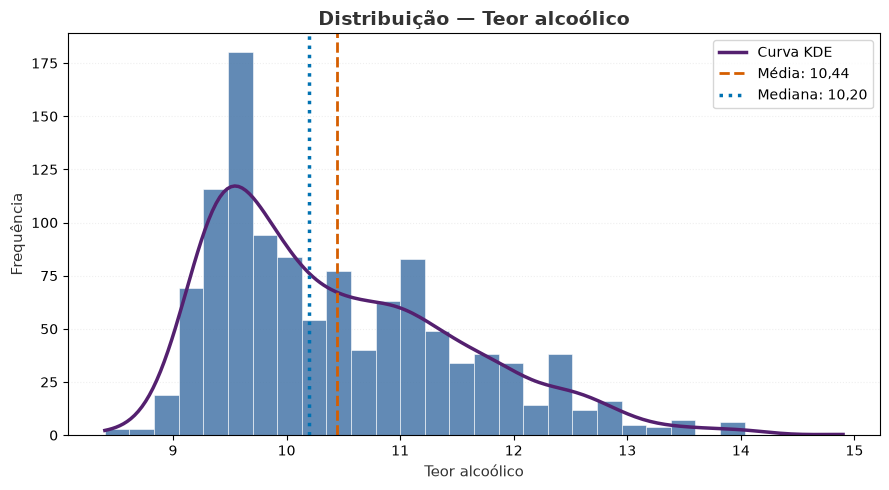

Análise da variável: Teor alcoólico
------------------------------------------------------------
Média: 10.4421
Mediana: 10.2000
Assimetria: 0.8633 — Assimétrica à direita — intensidade moderada
Curtose: 0.2212 — Mesocúrtica
Observação: a curva KDE auxilia na visualização do formato da distribuição.



In [28]:
# 7.1 Distribuição das Variáveis Explicativas

features = df.drop(
    columns=[
        "Id",
        "quality",
        "quality_label"
    ],
    errors="ignore"
).columns

analisador_distribuicao = AnalisadorDistribuicao(
    cor_histograma=COR_HISTOGRAMA,
    cor_kde=COR_KDE,
    cor_media=COR_MEDIA,
    cor_mediana=COR_MEDIANA,
    alpha_histograma=ALPHA_HISTOGRAMA,
    espessura_kde=ESPESSURA_KDE,
    bins=30
)

for coluna in features:

    nome_variavel = NOMES_VARIAVEIS.get(
        coluna,
        coluna
    )

    analisador_distribuicao.plotar_histograma(
        df=df,
        coluna=coluna,
        nome=nome_variavel
    )


### 7.2 Tabela-resumo da Distribuição das Variáveis

A tabela reúne média, mediana, assimetria e curtose para facilitar a comparação entre as distribuições.


In [29]:
# Tabela-Resumo da Distribuição das Variáveis

df_resumo_distribuicao = (
    analisador_distribuicao.gerar_tabela_resumo(
        df=df,
        colunas=features,
        nomes_variaveis=NOMES_VARIAVEIS
    )
)

display(df_resumo_distribuicao)


,Variável,Média,Mediana,Assimetria,Classificação da Assimetria,Curtose,Classificação da Curtose
0,Acidez fixa,8.31,7.90,1.04,Assimétrica à direita — intensidade elevada,1.38,Leptocúrtica — caudas mais pesadas
1,Acidez volátil,0.53,0.52,0.68,Assimétrica à direita — intensidade moderada,1.38,Leptocúrtica — caudas mais pesadas
2,Ácido cítrico,0.27,0.25,0.37,Aproximadamente simétrica,-0.71,Platicúrtica — caudas mais leves
3,Açúcar residual,2.53,2.20,4.36,Assimétrica à direita — intensidade elevada,27.68,Leptocúrtica — caudas mais pesadas
4,Cloretos,0.09,0.08,6.03,Assimétrica à direita — intensidade elevada,47.08,Leptocúrtica — caudas mais pesadas
5,Dióxido de enxofre livre,15.62,13.00,1.23,Assimétrica à direita — intensidade elevada,1.93,Leptocúrtica — caudas mais pesadas
6,Dióxido de enxofre total,45.91,37.00,1.67,Assimétrica à direita — intensidade elevada,5.10,Leptocúrtica — caudas mais pesadas
7,Densidade,1.00,1.00,0.10,Aproximadamente simétrica,0.89,Leptocúrtica — caudas mais pesadas
8,pH,3.31,3.31,0.22,Aproximadamente simétrica,0.93,Leptocúrtica — caudas mais pesadas
9,Sulfatos,0.66,0.62,2.50,Assimétrica à direita — intensidade elevada,12.02,Leptocúrtica — caudas mais pesadas


### Síntese da distribuição

As características físico-químicas não seguem um único padrão de distribuição. Algumas são próximas da simetria, enquanto outras apresentam assimetria e caudas mais longas.

Essa diferença de comportamento será considerada nas análises de correlação, outliers e modelagem.


### 7.3 Análise de Correlação

A correlação de Pearson é usada para observar relações lineares entre as características físico-químicas e a nota original `quality`, além das relações entre as próprias variáveis explicativas.

Os coeficientes variam de **-1 a 1**. Valores próximos dos extremos indicam associação linear mais forte; valores próximos de zero indicam associação linear fraca. Correlação não implica causalidade.


In [30]:
# 7.3 Análise de Correlação

matriz_correlacao = calcular_matriz_correlacao(df)

display(
    matriz_correlacao.round(2)
)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.00,-0.25,0.67,0.17,0.11,-0.16,-0.11,0.68,-0.69,0.17,-0.08,0.12
volatile acidity,-0.25,1.00,-0.54,-0.01,0.06,-0.00,0.08,0.02,0.22,-0.28,-0.20,-0.41
citric acid,0.67,-0.54,1.00,0.18,0.25,-0.06,0.04,0.38,-0.55,0.33,0.11,0.24
residual sugar,0.17,-0.01,0.18,1.00,0.07,0.17,0.19,0.38,-0.12,0.02,0.06,0.02
chlorides,0.11,0.06,0.25,0.07,1.00,0.02,0.05,0.21,-0.28,0.37,-0.23,-0.12
free sulfur dioxide,-0.16,-0.00,-0.06,0.17,0.02,1.00,0.66,-0.05,0.07,0.03,-0.05,-0.06
total sulfur dioxide,-0.11,0.08,0.04,0.19,0.05,0.66,1.00,0.05,-0.06,0.03,-0.19,-0.18
density,0.68,0.02,0.38,0.38,0.21,-0.05,0.05,1.00,-0.35,0.14,-0.49,-0.18
pH,-0.69,0.22,-0.55,-0.12,-0.28,0.07,-0.06,-0.35,1.00,-0.19,0.23,-0.05
sulphates,0.17,-0.28,0.33,0.02,0.37,0.03,0.03,0.14,-0.19,1.00,0.09,0.26


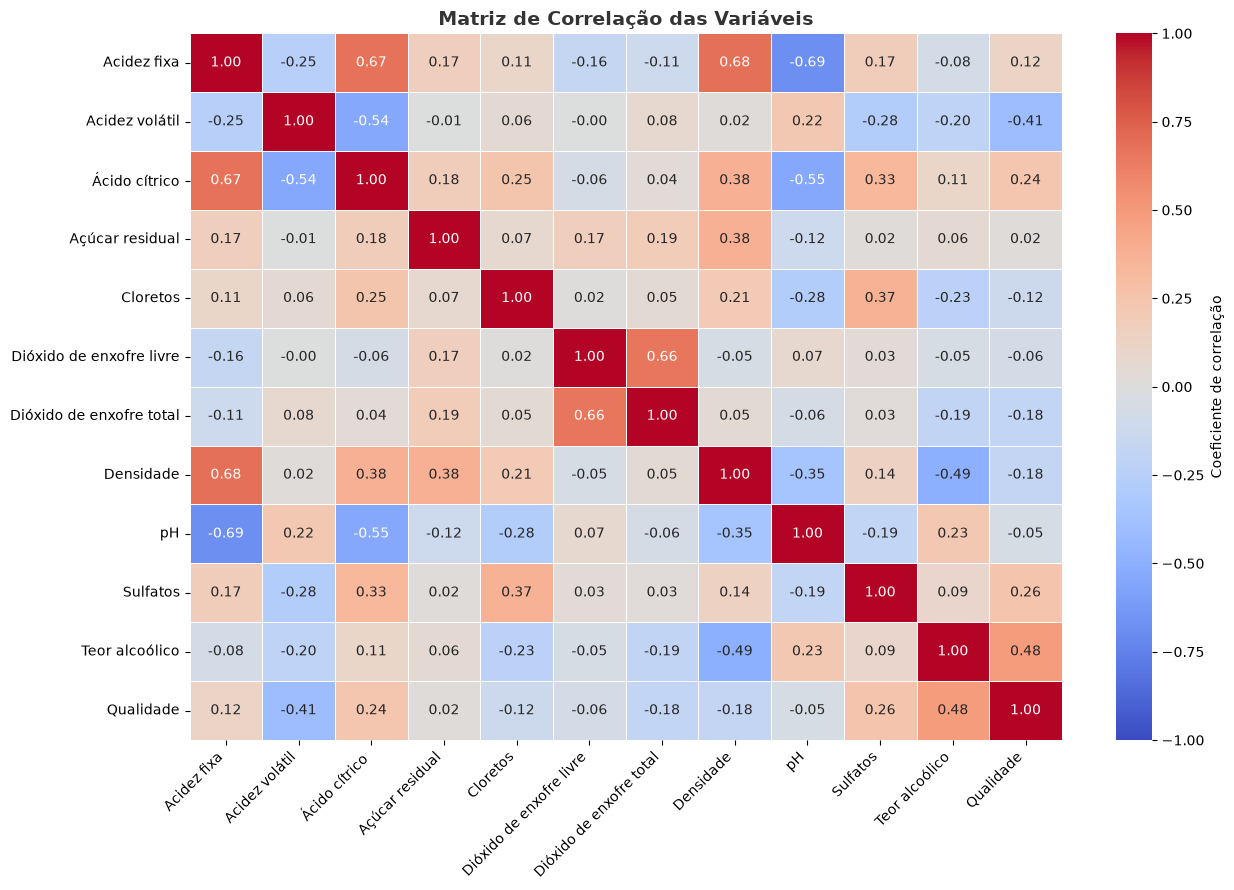

In [31]:
# Visualização da Matriz de Correlação

plotar_matriz_correlacao(
    matriz_correlacao
)


### 7.4 Análise Visual de Outliers

Os boxplots são usados para localizar valores mais afastados do comportamento central de cada variável.

Um ponto identificado como outlier não será removido automaticamente. Antes disso, é necessário avaliar se ele representa erro ou uma observação válida da base.


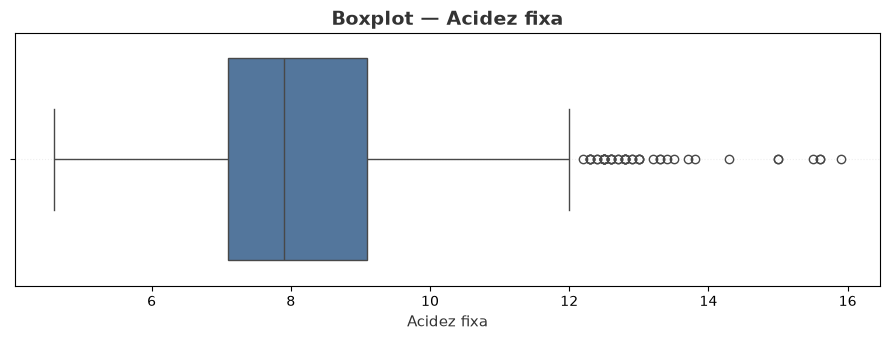

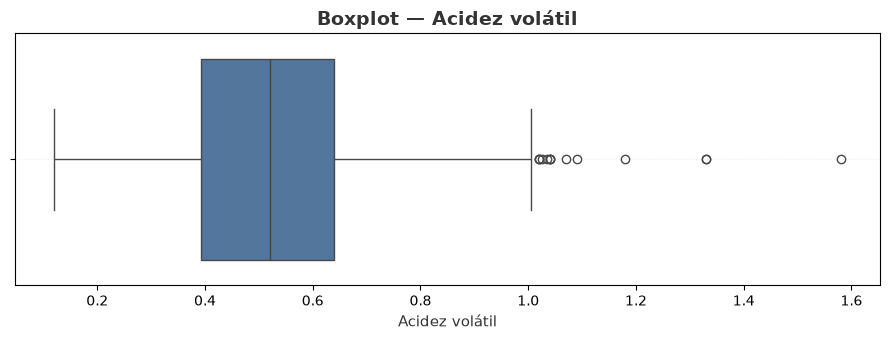

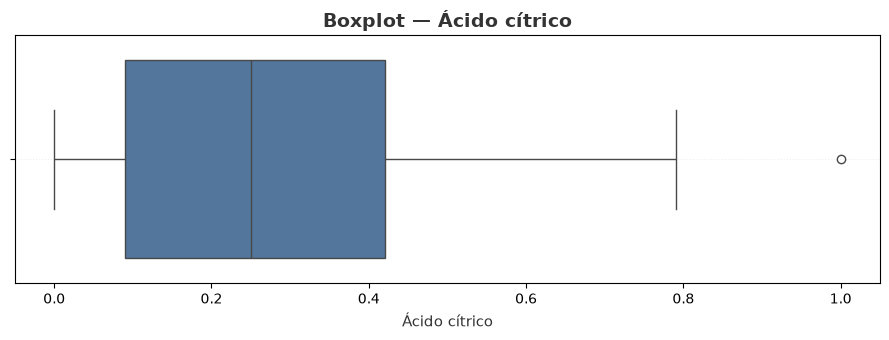

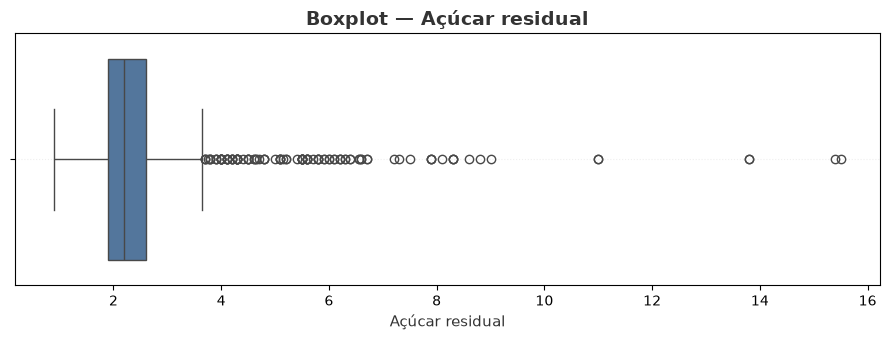

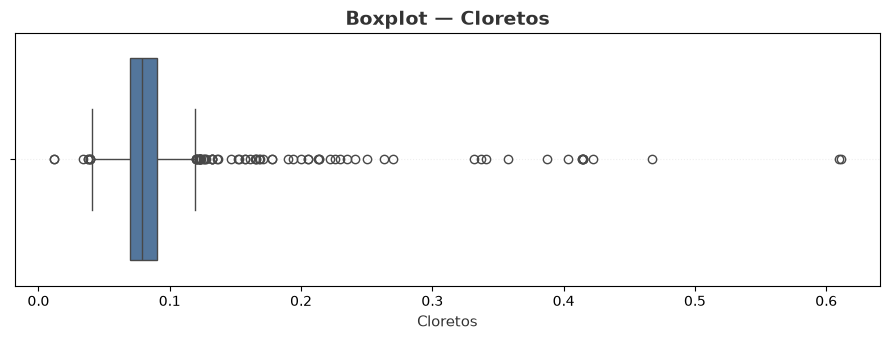

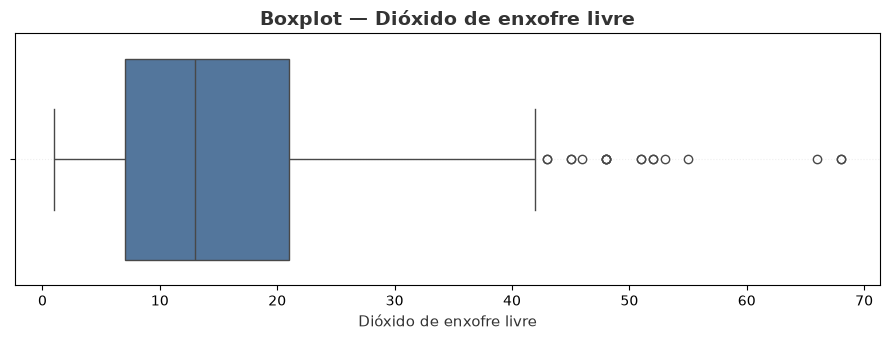

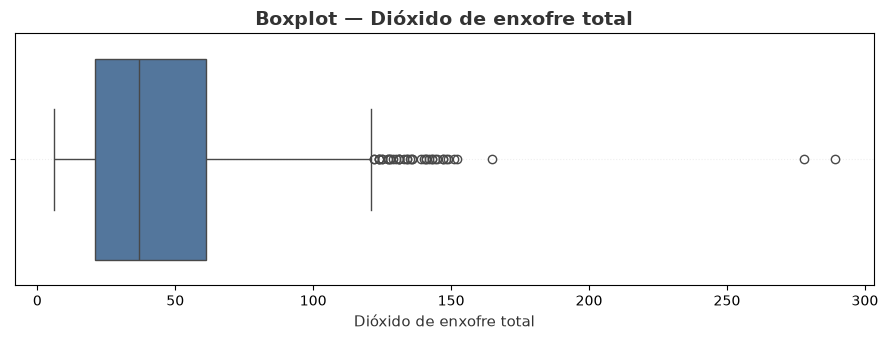

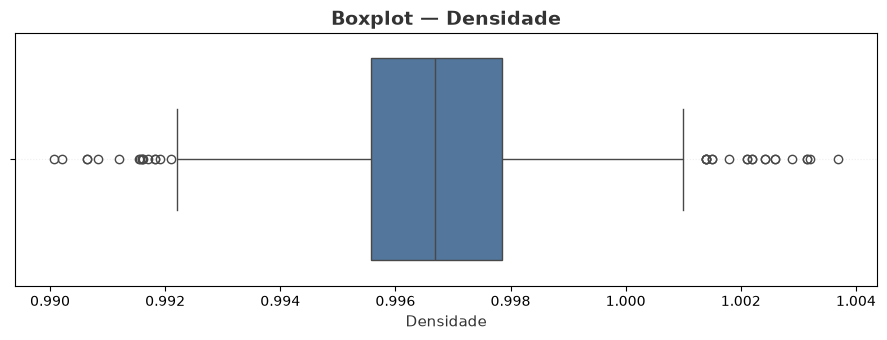

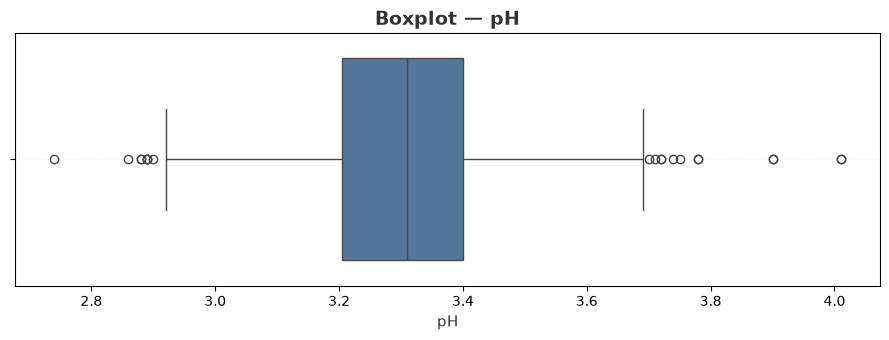

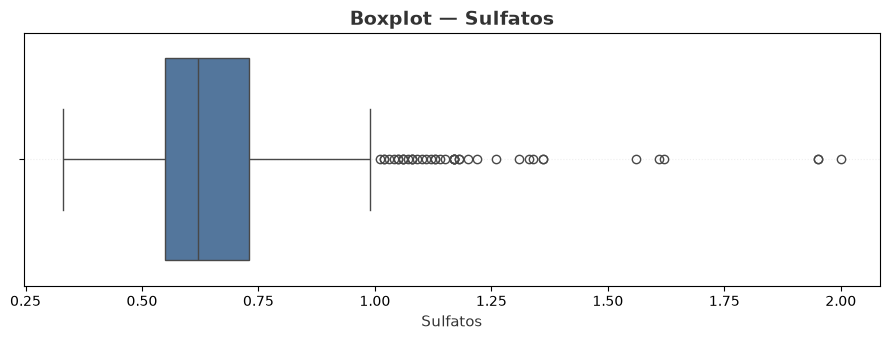

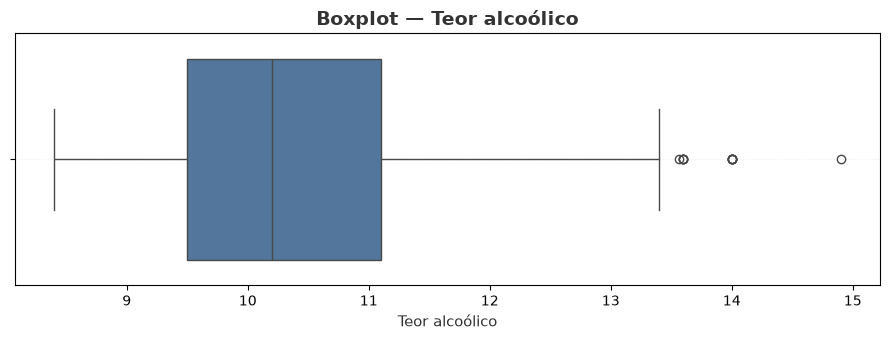

In [32]:
# 7.4 Análise Visual de Outliers

colunas_outliers = features

for coluna in colunas_outliers:

    nome_variavel = NOMES_VARIAVEIS.get(
        coluna,
        coluna
    )

    plt.figure(
        figsize=(9, 3.5)
    )

    sns.boxplot(
        x=df[coluna],
        color=COR_BOXPLOT
    )

    grafico_format(
        titulo=f"Boxplot — {nome_variavel}",
        xlabel=nome_variavel,
        ylabel=""
    )

    salvar_grafico(
        f"boxplot_{coluna}"
    )

    plt.show()


### 7.5 Quantificação dos Outliers

Além da inspeção visual, os valores extremos são quantificados pelo método do **Intervalo Interquartil (IQR)**. A tabela mostra quantos registros ficam abaixo ou acima dos limites calculados para cada variável.


In [33]:
# Quantificação dos Outliers Pelo Método Iqr

resultado_outliers = []

for coluna in features:

    q1 = df[coluna].quantile(0.25)
    q3 = df[coluna].quantile(0.75)
    iqr = q3 - q1

    # Define os limites pelo critério de 1,5 × IQR.
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    quantidade = (
        (df[coluna] < limite_inferior)
        | (df[coluna] > limite_superior)
    ).sum()

    percentual = quantidade / len(df) * 100

    resultado_outliers.append({
        "Variável": NOMES_VARIAVEIS.get(coluna, coluna),
        "Outliers": quantidade,
        "Percentual (%)": round(percentual, 2)
    })

df_outliers = (
    pd.DataFrame(resultado_outliers)
    .sort_values(
        by="Outliers",
        ascending=False
    )
    .reset_index(drop=True)
)

display(df_outliers)


,Variável,Outliers,Percentual (%)
0,Açúcar residual,110,9.62
1,Cloretos,77,6.74
2,Acidez fixa,44,3.85
3,Sulfatos,43,3.76
4,Dióxido de enxofre total,40,3.50
5,Densidade,36,3.15
6,pH,20,1.75
7,Dióxido de enxofre livre,18,1.57
8,Acidez volátil,14,1.22
9,Teor alcoólico,12,1.05


### Resultado da análise

O método IQR identificou valores extremos em todas as variáveis, com maior ocorrência em **Açúcar residual (9,62%)**, **Cloretos (6,74%)**, **Acidez fixa (3,85%)** e **Sulfatos (3,76%)**.

O **Ácido cítrico** apresentou a menor ocorrência pelo critério adotado, com **0,09%**. Esses registros foram mantidos, pois o método apenas sinaliza valores afastados e não indica, por si só, erro de medição.


### 7.6 Relação das Variáveis com a Variável Alvo

As características físico-químicas são comparadas entre **Baixa/Média Qualidade** e **Alta Qualidade**. A comparação usa média, mediana e visualizações por classe para identificar diferenças que possam ser relevantes na modelagem.


In [34]:
# 7.6 Relação das Variáveis Com A Variável Alvo

df_comparacao_alvo = df[
    list(features) + ["quality_label"]
].copy()

media_por_classe = (
    df_comparacao_alvo
    .groupby("quality_label")[list(features)]
    .mean()
    .T
)

mediana_por_classe = (
    df_comparacao_alvo
    .groupby("quality_label")[list(features)]
    .median()
    .T
)

tabela_comparacao_alvo = pd.DataFrame({
    "Média — Baixa/Média": media_por_classe[0],
    "Média — Alta": media_por_classe[1],
    "Mediana — Baixa/Média": mediana_por_classe[0],
    "Mediana — Alta": mediana_por_classe[1]
}).round(4)

tabela_comparacao_alvo.index = [
    NOMES_VARIAVEIS.get(coluna, coluna)
    for coluna in tabela_comparacao_alvo.index
]

display(tabela_comparacao_alvo)


,Média — Baixa/Média,Média — Alta,Mediana — Baixa/Média,Mediana — Alta
Acidez fixa,8.2246,8.8465,7.8000,8.7000
Acidez volátil,0.5533,0.3953,0.5500,0.3600
Ácido cítrico,0.2485,0.3912,0.2400,0.4100
Açúcar residual,2.4972,2.7484,2.2000,2.3000
Cloretos,0.0889,0.0747,0.0800,0.0730
Dióxido de enxofre livre,15.8460,14.1887,14.0000,12.0000
Dióxido de enxofre total,47.4080,36.6730,39.0000,28.0000
Densidade,0.9968,0.9960,0.9968,0.9957
pH,3.3156,3.2825,3.3150,3.2700
Sulfatos,0.6435,0.7458,0.6000,0.7400


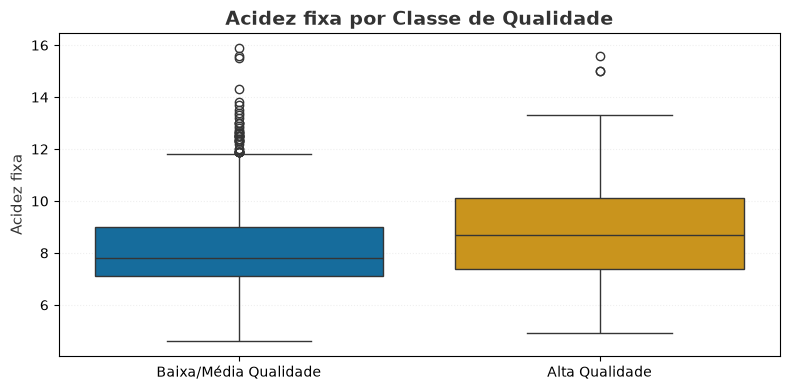

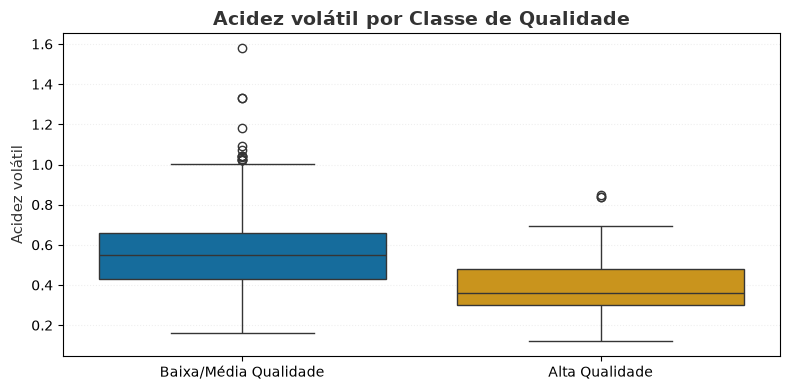

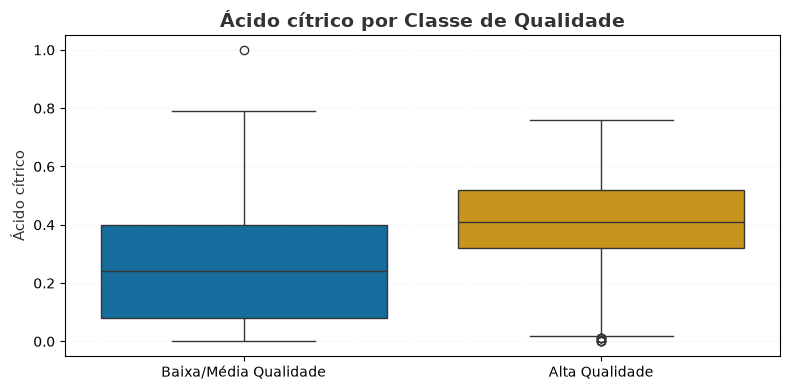

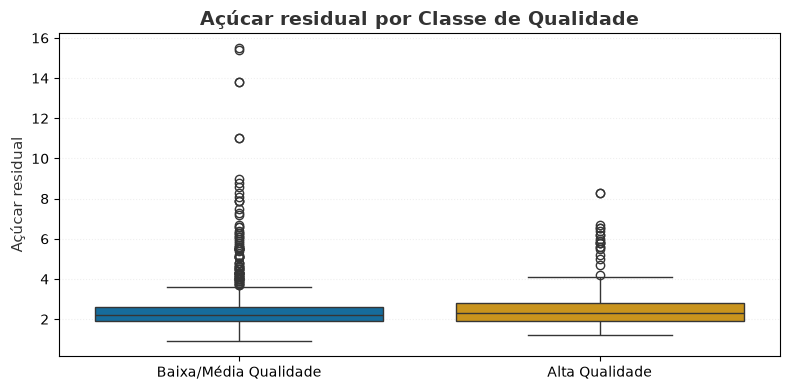

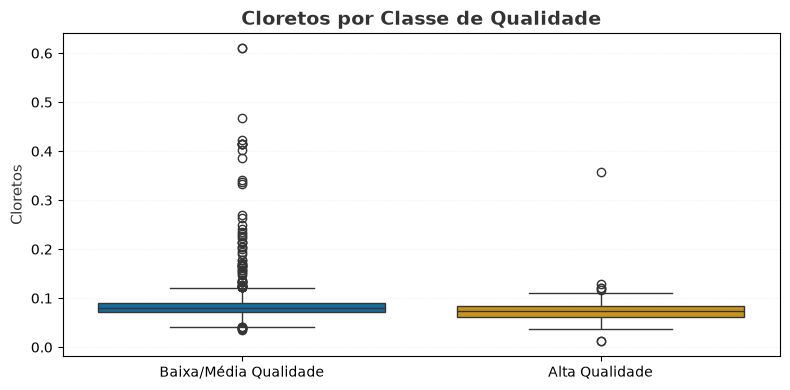

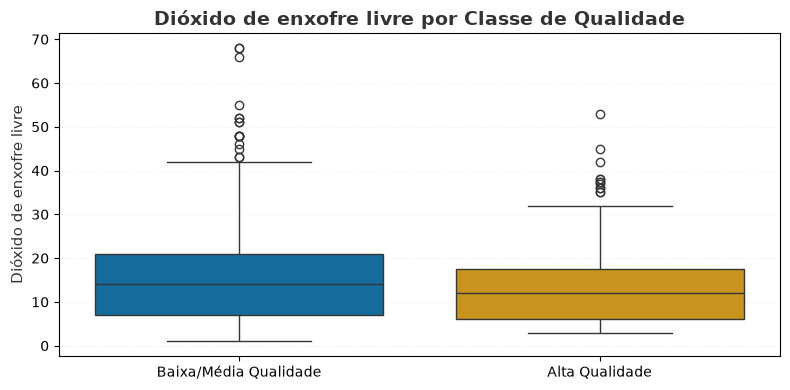

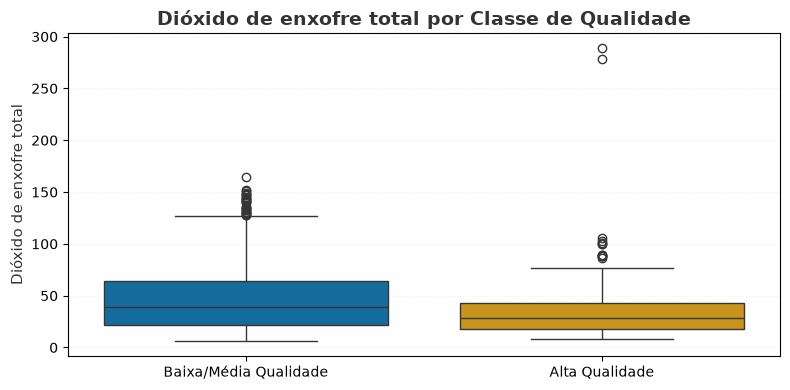

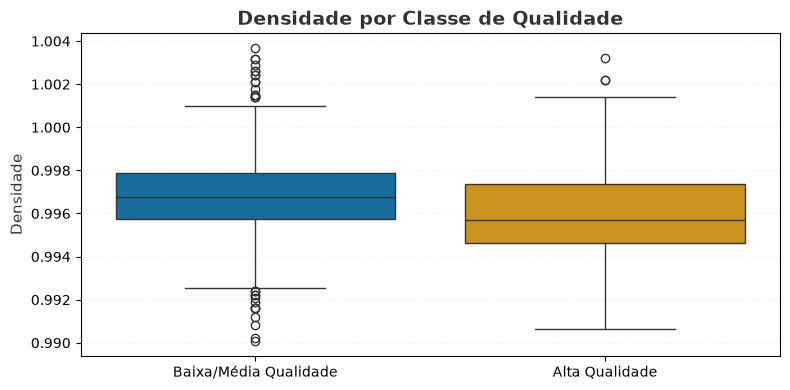

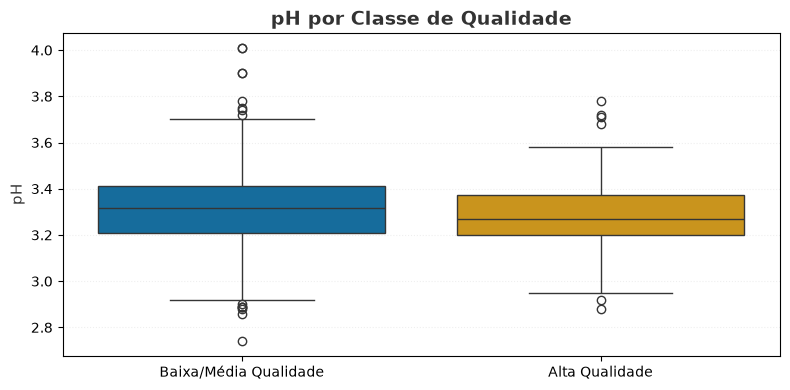

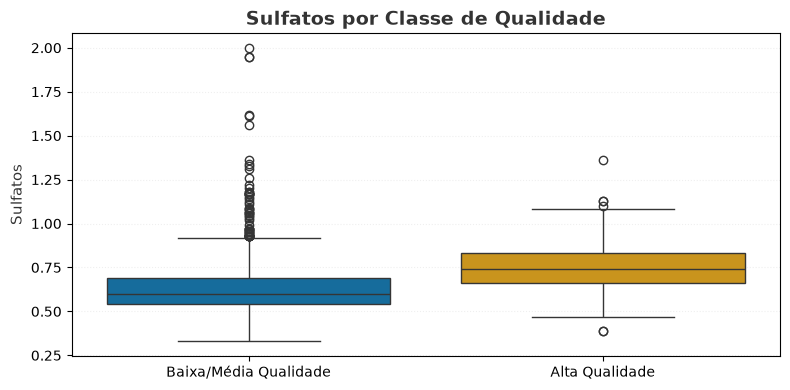

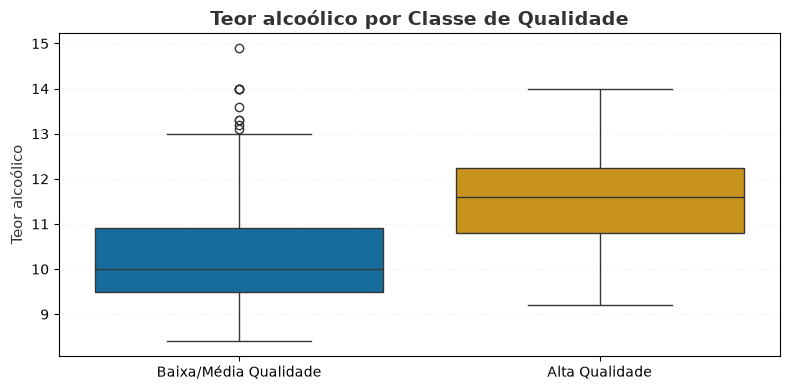

In [35]:
# Comparação das Variáveis Entre As Classes

df_comparacao_alvo["Classe"] = (
    df_comparacao_alvo["quality_label"]
    .map({
        0: "Baixa/Média Qualidade",
        1: "Alta Qualidade"
    })
)

for coluna in features:

    nome_variavel = NOMES_VARIAVEIS.get(
        coluna,
        coluna
    )

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        data=df_comparacao_alvo,
        x="Classe",
        y=coluna,
        hue="Classe",
        palette=PALETA_CATEGORICA[:2],
        legend=False
    )

    grafico_format(
        titulo=f"{nome_variavel} por Classe de Qualidade",
        xlabel="",
        ylabel=nome_variavel
    )

    salvar_grafico(
        f"comparacao_classe_{coluna}"
    )

    plt.show()


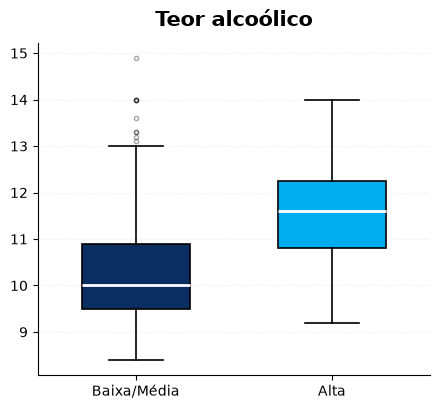

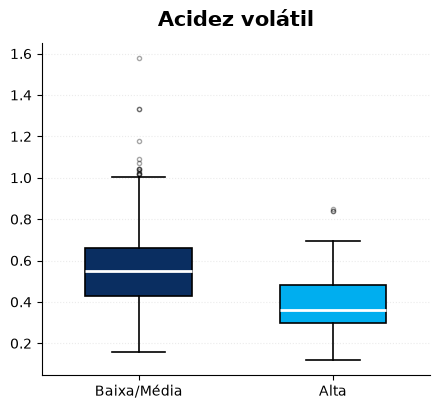

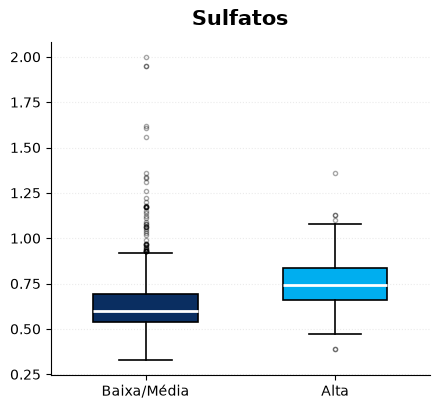

In [36]:
import matplotlib.pyplot as plt

# Cores próximas ao padrão do seu PPT
COR_BAIXA_MEDIA = "#0A2E61"
COR_ALTA = "#00AEEF"

variaveis = {
    "alcohol": "Teor alcoólico",
    "volatile acidity": "Acidez volátil",
    "sulphates": "Sulfatos"
}

for coluna, titulo in variaveis.items():

    baixa_media = df.loc[df["quality_label"] == 0, coluna].dropna()
    alta = df.loc[df["quality_label"] == 1, coluna].dropna()

    fig, ax = plt.subplots(figsize=(4.5, 4.2))

    box = ax.boxplot(
        [baixa_media, alta],
        tick_labels=["Baixa/Média", "Alta"],
        patch_artist=True,
        widths=0.55,
        medianprops={"color": "white", "linewidth": 2},
        boxprops={"linewidth": 1.2},
        whiskerprops={"linewidth": 1.2},
        capprops={"linewidth": 1.2},
        flierprops={
            "marker": "o",
            "markersize": 3,
            "alpha": 0.35
        }
    )

    box["boxes"][0].set_facecolor(COR_BAIXA_MEDIA)
    box["boxes"][1].set_facecolor(COR_ALTA)

    ax.set_title(
        titulo,
        fontsize=15,
        fontweight="bold",
        pad=12
    )

    ax.set_xlabel("")
    ax.grid(axis="y", linestyle=":", alpha=0.25)

    # Remove bordas desnecessárias
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    nome_arquivo = titulo.lower().replace(" ", "_").replace("ó", "o")
    plt.savefig(
        f"{nome_arquivo}.png",
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.show()

#### Síntese

A comparação entre as classes mostrou diferenças mais claras em **teor alcoólico, acidez volátil, ácido cítrico e sulfatos**. Essas diferenças serão observadas novamente na etapa de modelagem, sem assumir relação causal.


## 8. Pré-processamento dos Dados

Nesta etapa, as variáveis são organizadas para a modelagem. O processo inclui a separação entre entrada e alvo, a divisão entre treino e teste e a padronização dos modelos que dependem de escala.


### 8.1 Engenharia de Atributos (Feature Engineering)

A partir das análises realizadas, optou-se por **manter as características físico-químicas originais**, sem criar novas variáveis explicativas nesta etapa.

A decisão permite avaliar primeiro o desempenho dos modelos com as informações já disponíveis, antes de considerar a criação de novos atributos.


In [37]:
# 8.1 Engenharia de Atributos (Feature Engineering)

resumo_feature_engineering = pd.DataFrame({
    "Etapa": [
        "Criação de novas variáveis"
    ],
    "Decisão": [
        "Não realizada nesta etapa"
    ],
    "Justificativa": [
        "Avaliar inicialmente os modelos com as características físico-químicas originais."
    ]
})

display(resumo_feature_engineering)


,Etapa,Decisão,Justificativa
0,Criação de novas variáveis,Não realizada nesta etapa,Avaliar inicialmente os modelos com as caracte...


### 8.2 Tratamento de Dados Faltantes

A verificação anterior mostrou que a base não possui valores ausentes. Por isso, não é necessário aplicar remoção ou imputação de dados.


In [38]:
# 8.2 Tratamento de Dados Faltantes

total_faltantes = df.isna().sum().sum()

print(
    f"Total de valores faltantes: {total_faltantes}"
)


Total de valores faltantes: 0


### 8.3 Preparação das Variáveis para Modelagem

As características físico-químicas formam o conjunto de entrada, enquanto `quality_label` é a variável alvo.

`Id` é excluído por ser apenas um identificador. A coluna `quality` também é retirada porque foi usada para criar `quality_label`; mantê-la no treinamento causaria vazamento de informação.


In [39]:
# 8.3 Preparação das Variáveis para Modelagem

caracteristicas_vinho = df.drop(
    columns=[
        "Id",
        "quality",
        "quality_label"
    ]
)

classe_qualidade = df["quality_label"]

quantidade_por_classe = classe_qualidade.value_counts()

resumo_separacao = pd.DataFrame({
    "Informação": [
        "Registros em X",
        "Variáveis explicativas",
        "Registros em y",
        "Baixa/Média Qualidade",
        "Alta Qualidade"
    ],
    "Resultado": [
        caracteristicas_vinho.shape[0],
        caracteristicas_vinho.shape[1],
        classe_qualidade.shape[0],
        quantidade_por_classe.get(0, 0),
        quantidade_por_classe.get(1, 0)
    ]
})

display(resumo_separacao)


,Informação,Resultado
0,Registros em X,1143
1,Variáveis explicativas,11
2,Registros em y,1143
3,Baixa/Média Qualidade,984
4,Alta Qualidade,159


### 8.4 Divisão dos Dados em Treino e Teste

A base é dividida em **80% para treino e 20% para teste**. A estratificação mantém aproximadamente a proporção das classes nos dois conjuntos, e `random_state=42` torna a divisão reproduzível.


In [40]:
# 8.4 Divisão dos Dados Em Treino e Teste

(
    caracteristicas_treino,
    caracteristicas_teste,
    classe_treino,
    classe_teste
) = train_test_split(
    caracteristicas_vinho,
    classe_qualidade,
    test_size=0.20,
    random_state=42,
    stratify=classe_qualidade
)

resumo_divisao = pd.DataFrame({
    "Conjunto": [
        "Treino",
        "Teste"
    ],
    "Quantidade de Registros": [
        len(caracteristicas_treino),
        len(caracteristicas_teste)
    ],
    "Percentual da Base": [
        len(caracteristicas_treino) / len(caracteristicas_vinho) * 100,
        len(caracteristicas_teste) / len(caracteristicas_vinho) * 100
    ],
    "Alta Qualidade (%)": [
        classe_treino.mean() * 100,
        classe_teste.mean() * 100
    ]
}).round(2)

display(resumo_divisao)


,Conjunto,Quantidade de Registros,Percentual da Base,Alta Qualidade (%)
0,Treino,914,79.97,13.89
1,Teste,229,20.03,13.97


### 8.5 Padronização das Variáveis Numéricas

As características têm escalas diferentes, o que pode afetar algoritmos baseados em distância ou otimização.

O `StandardScaler` é ajustado apenas com os dados de treino e depois aplicado ao teste. Regressão Logística e KNN usam os dados padronizados; Random Forest e Gradient Boosting trabalham com a escala original.


In [41]:
# 8.5 Padronização das Variáveis Numéricas

padronizador = StandardScaler()

caracteristicas_treino_padronizadas = padronizador.fit_transform(
    caracteristicas_treino
)

caracteristicas_teste_padronizadas = padronizador.transform(
    caracteristicas_teste
)

caracteristicas_treino_padronizadas = pd.DataFrame(
    caracteristicas_treino_padronizadas,
    columns=caracteristicas_treino.columns,
    index=caracteristicas_treino.index
)

caracteristicas_teste_padronizadas = pd.DataFrame(
    caracteristicas_teste_padronizadas,
    columns=caracteristicas_teste.columns,
    index=caracteristicas_teste.index
)

comparacao_padronizacao = pd.DataFrame({
    "Média (Antes)":
        caracteristicas_treino.mean(),

    "Média (Depois)":
        caracteristicas_treino_padronizadas.mean(),

    "Desvio-Padrão (Antes)":
        caracteristicas_treino.std(ddof=0),

    "Desvio-Padrão (Depois)":
        caracteristicas_treino_padronizadas.std(ddof=0)
}).round(2)

display(comparacao_padronizacao)


,Média (Antes),Média (Depois),Desvio-Padrão (Antes),Desvio-Padrão (Depois)
fixed acidity,8.32,-0.0,1.76,1.0
volatile acidity,0.53,-0.0,0.17,1.0
citric acid,0.27,-0.0,0.19,1.0
residual sugar,2.55,0.0,1.44,1.0
chlorides,0.09,-0.0,0.04,1.0
free sulfur dioxide,15.25,-0.0,9.96,1.0
total sulfur dioxide,45.28,-0.0,33.20,1.0
density,1.00,0.0,0.00,1.0
pH,3.31,-0.0,0.16,1.0
sulphates,0.66,0.0,0.17,1.0


#### Verificação

Após a transformação, as variáveis de treino ficaram com média próxima de zero e desvio-padrão próximo de um. A padronização será usada apenas nos modelos sensíveis à escala: Regressão Logística e KNN.


## 9. Modelagem de Machine Learning





### 9.1 Regressão Logística

A Regressão Logística é usada como modelo inicial de referência para a classificação binária. Como o algoritmo pode ser sensível à escala, o treinamento utiliza as variáveis padronizadas.


In [42]:
# 9.1 Regressão Logística

modelo_regressao_logistica = LogisticRegression(
    random_state=42,
    max_iter=1000
)

previsoes_regressao_logistica = treinar_e_prever_modelo(
    modelo=modelo_regressao_logistica,
    caracteristicas_treino_modelo=caracteristicas_treino_padronizadas,
    classe_treino_modelo=classe_treino,
    caracteristicas_teste_modelo=caracteristicas_teste_padronizadas
)

print(
    f"Quantidade de previsões realizadas: "
    f"{len(previsoes_regressao_logistica)}"
)


Quantidade de previsões realizadas: 229


### 9.2 Random Forest

O Random Forest combina várias árvores de decisão e consegue representar relações não lineares entre as variáveis. Como a escala não interfere nas divisões das árvores, o modelo usa os dados originais.


In [43]:
# 9.2 Random Forest

modelo_random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

previsoes_random_forest = treinar_e_prever_modelo(
    modelo=modelo_random_forest,
    caracteristicas_treino_modelo=caracteristicas_treino,
    classe_treino_modelo=classe_treino,
    caracteristicas_teste_modelo=caracteristicas_teste
)

print(
    f"Quantidade de previsões realizadas: "
    f"{len(previsoes_random_forest)}"
)


Quantidade de previsões realizadas: 229


### 9.3 K-Nearest Neighbors (KNN)

O KNN classifica cada observação a partir dos vizinhos mais próximos. Como a distância entre pontos depende da escala das variáveis, são usados os dados padronizados. A primeira configuração utiliza `k = 5`.


In [44]:
# 9.3 K-Nearest Neighbors (Knn)

quantidade_vizinhos_knn = 5

modelo_knn = KNeighborsClassifier(
    n_neighbors=quantidade_vizinhos_knn
)

previsoes_knn = treinar_e_prever_modelo(
    modelo=modelo_knn,
    caracteristicas_treino_modelo=caracteristicas_treino_padronizadas,
    classe_treino_modelo=classe_treino,
    caracteristicas_teste_modelo=caracteristicas_teste_padronizadas
)

print(
    f"Quantidade de previsões realizadas: "
    f"{len(previsoes_knn)}"
)

print(
    f"Quantidade de vizinhos utilizada no KNN: "
    f"{quantidade_vizinhos_knn}"
)


Quantidade de previsões realizadas: 229
Quantidade de vizinhos utilizada no KNN: 5


### 9.4 Gradient Boosting

O Gradient Boosting constrói árvores de forma sequencial, usando cada nova etapa para reduzir erros das anteriores. O modelo é treinado com as características na escala original.


In [45]:
# 9.4 Gradient Boosting

modelo_gradient_boosting = GradientBoostingClassifier(
    random_state=42
)

previsoes_gradient_boosting = treinar_e_prever_modelo(
    modelo=modelo_gradient_boosting,
    caracteristicas_treino_modelo=caracteristicas_treino,
    classe_treino_modelo=classe_treino,
    caracteristicas_teste_modelo=caracteristicas_teste
)

print(
    f"Quantidade de previsões realizadas: "
    f"{len(previsoes_gradient_boosting)}"
)


Quantidade de previsões realizadas: 229


## 10. Avaliação dos Modelos

### 10.1 Avaliação da Regressão Logística

A Regressão Logística é avaliada com **Accuracy, Precision, Recall e F1-Score**, considerando **Alta Qualidade (1)** como classe positiva. A matriz de confusão complementa a leitura das métricas.


In [46]:
# 10.1 Avaliação da Regressão Logística

resultados_regressao_logistica = avaliar_classe_alta_qualidade(
    classe_real=classe_teste,
    previsoes=previsoes_regressao_logistica,
    classe_positiva=1
)

resultados_regressao_logistica["Acurácia"] = accuracy_score(
    classe_teste,
    previsoes_regressao_logistica
)

tabela_regressao_logistica = pd.DataFrame(
    resultados_regressao_logistica,
    index=["Regressão Logística"]
).round(4)

display(tabela_regressao_logistica)


,Precision,Recall,F1-Score,Acurácia
Regressão Logística,0.5238,0.3438,0.4151,0.8646


In [47]:
# Métricas da Regressão Logística

ordem_metricas = [
    "Acurácia",
    "Precision",
    "Recall",
    "F1-Score"
]

tabela_metricas_regressao = pd.DataFrame({
    "Métrica": ordem_metricas,
    "Resultado (%)": [
        resultados_regressao_logistica[metrica] * 100
        for metrica in ordem_metricas
    ]
})

display(
    tabela_metricas_regressao.style
    .hide(axis="index")
    .format({
        "Resultado (%)": "{:.2f}%"
    })
    .set_caption(
        "Métricas da Regressão Logística"
    )
)


Métrica,Resultado (%)
Acurácia,86.46%
Precision,52.38%
Recall,34.38%
F1-Score,41.51%


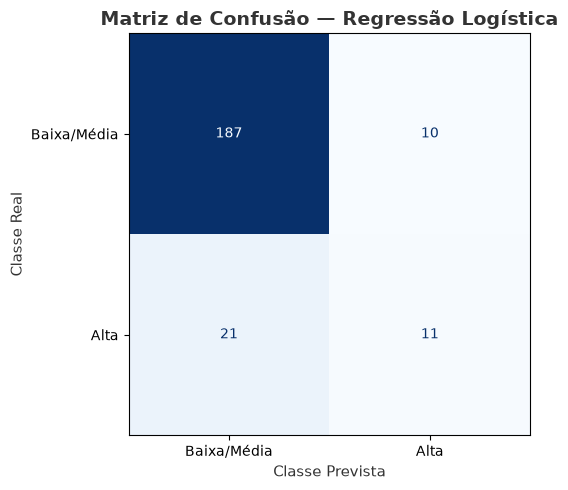

In [48]:
# Figura 10.1 - Matriz de Confusão da Regressão Logística

figura, eixo = plt.subplots(
    figsize=(6, 5)
)

ConfusionMatrixDisplay.from_predictions(
    classe_teste,
    previsoes_regressao_logistica,
    display_labels=[
        "Baixa/Média",
        "Alta"
    ],
    cmap="Blues",
    values_format="d",
    colorbar=False,
    ax=eixo
)

eixo.set_title(
    "Matriz de Confusão — Regressão Logística",
    fontsize=14,
    fontweight="bold",
    color=CORES["texto"]
)

eixo.set_xlabel(
    "Classe Prevista",
    fontsize=11,
    color=CORES["texto"]
)

eixo.set_ylabel(
    "Classe Real",
    fontsize=11,
    color=CORES["texto"]
)

plt.tight_layout()

salvar_grafico(
    "matriz_confusao_regressao_logistica"
)

plt.show()


#### Resultado

A Regressão Logística alcançou **86,46% de Accuracy**, mas o desempenho na classe Alta Qualidade foi mais baixo: **52,38% de Precision**, **34,38% de Recall** e **41,51% de F1-Score**.

A matriz de confusão confirma que o modelo identifica melhor a classe Baixa/Média do que a classe Alta. Por isso, a Accuracy isolada não é suficiente para avaliar esse modelo.


### 10.2 Avaliação do Random Forest

O Random Forest é avaliado com as mesmas métricas usadas na Regressão Logística, o que permite comparar os modelos sob o mesmo critério.


In [49]:
# 10.2 Avaliação do Random Forest

resultados_random_forest = avaliar_classe_alta_qualidade(
    classe_real=classe_teste,
    previsoes=previsoes_random_forest,
    classe_positiva=1
)

resultados_random_forest["Acurácia"] = accuracy_score(
    classe_teste,
    previsoes_random_forest
)


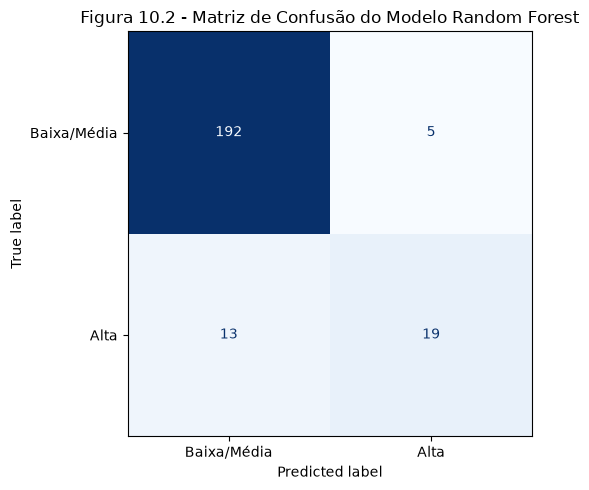

In [50]:
# Figura 10.2 - Matriz de Confusão do Modelo Random Forest

figura, eixo = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    classe_teste,
    previsoes_random_forest,
    display_labels=[
        "Baixa/Média",
        "Alta"
    ],
    cmap="Blues",
    values_format="d",
    colorbar=False,
    ax=eixo
)

eixo.set_title(
    "Figura 10.2 - Matriz de Confusão do Modelo Random Forest"
)

plt.tight_layout()
plt.show()


In [51]:
# Tabela 10.3 - Métricas do Random Forest

ordem_metricas = [
    "Acurácia",
    "Precision",
    "Recall",
    "F1-Score"
]

tabela_metricas_random_forest = pd.DataFrame({
    "Métrica": ordem_metricas,
    "Resultado (%)": [
        resultados_random_forest[metrica] * 100
        for metrica in ordem_metricas
    ]
})

display(
    tabela_metricas_random_forest.style
    .hide(axis="index")
    .format({
        "Resultado (%)": "{:.2f}%"
    })
    .set_caption(
        "Métricas do Random Forest"
    )
)


Métrica,Resultado (%)
Acurácia,92.14%
Precision,79.17%
Recall,59.38%
F1-Score,67.86%


#### Resultado

O Random Forest apresentou **92,14% de Accuracy**, **79,17% de Precision**, **59,38% de Recall** e **67,86% de F1-Score**.

Nesse primeiro teste, os resultados foram superiores aos da Regressão Logística, principalmente na identificação da classe Alta Qualidade.


### 10.3 Avaliação do K-Nearest Neighbors (KNN)

O KNN é avaliado com **Accuracy, Precision, Recall e F1-Score**, considerando **Alta Qualidade (1)** como classe positiva. A matriz de confusão mostra a distribuição dos acertos e erros.


In [52]:
# 10.4 Avaliação do K-Nearest Neighbors (Knn)

resultados_knn = avaliar_classe_alta_qualidade(
    classe_real=classe_teste,
    previsoes=previsoes_knn,
    classe_positiva=1
)

resultados_knn["Acurácia"] = accuracy_score(
    classe_teste,
    previsoes_knn
)


In [53]:
# Tabela de Métricas do Knn

ordem_metricas = [
    "Acurácia",
    "Precision",
    "Recall",
    "F1-Score"
]

tabela_metricas_knn = pd.DataFrame({
    "Métrica": ordem_metricas,
    "Resultado (%)": [
        resultados_knn[metrica] * 100
        for metrica in ordem_metricas
    ]
})

display(
    tabela_metricas_knn.style
    .hide(axis="index")
    .format({
        "Resultado (%)": "{:.2f}%"
    })
    .set_caption(
        "Métricas do K-Nearest Neighbors (KNN)"
    )
)


Métrica,Resultado (%)
Acurácia,86.46%
Precision,51.85%
Recall,43.75%
F1-Score,47.46%


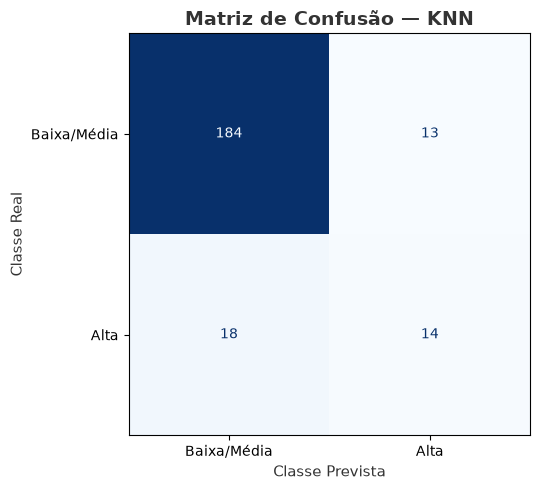

In [54]:
# Figura 10.4 - Matriz de Confusão do Knn

figura, eixo = plt.subplots(
    figsize=(6, 5)
)

ConfusionMatrixDisplay.from_predictions(
    classe_teste,
    previsoes_knn,
    display_labels=[
        "Baixa/Média",
        "Alta"
    ],
    cmap="Blues",
    values_format="d",
    colorbar=False,
    ax=eixo
)

eixo.set_title(
    "Matriz de Confusão — KNN",
    fontsize=14,
    fontweight="bold",
    color=CORES["texto"]
)

eixo.set_xlabel(
    "Classe Prevista",
    fontsize=11,
    color=CORES["texto"]
)

eixo.set_ylabel(
    "Classe Real",
    fontsize=11,
    color=CORES["texto"]
)

plt.tight_layout()

salvar_grafico(
    "matriz_confusao_knn"
)

plt.show()


Métrica,Resultado (%)
Acurácia,86.46%
Precision,51.85%
Recall,43.75%
F1-Score,47.46%


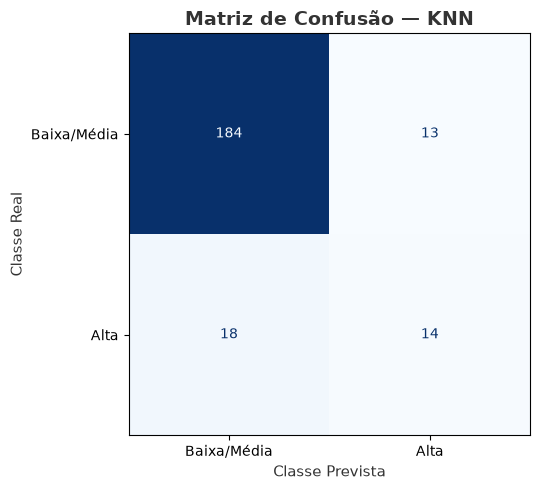

In [55]:
# 10.3 Avaliação do K-Nearest Neighbors (Knn)

resultados_knn = avaliar_classe_alta_qualidade(
    classe_real=classe_teste,
    previsoes=previsoes_knn,
    classe_positiva=1
)

resultados_knn["Acurácia"] = accuracy_score(
    classe_teste,
    previsoes_knn
)

ordem_metricas = [
    "Acurácia",
    "Precision",
    "Recall",
    "F1-Score"
]

tabela_metricas_knn = pd.DataFrame({
    "Métrica": ordem_metricas,
    "Resultado (%)": [
        resultados_knn[metrica] * 100
        for metrica in ordem_metricas
    ]
})

display(
    tabela_metricas_knn.style
    .hide(axis="index")
    .format({
        "Resultado (%)": "{:.2f}%"
    })
    .set_caption(
        "Métricas do K-Nearest Neighbors (KNN)"
    )
)

figura, eixo = plt.subplots(
    figsize=(6, 5)
)

ConfusionMatrixDisplay.from_predictions(
    classe_teste,
    previsoes_knn,
    display_labels=[
        "Baixa/Média",
        "Alta"
    ],
    cmap="Blues",
    values_format="d",
    colorbar=False,
    ax=eixo
)

eixo.set_title(
    "Matriz de Confusão — KNN",
    fontsize=14,
    fontweight="bold",
    color=CORES["texto"]
)

eixo.set_xlabel(
    "Classe Prevista",
    fontsize=11,
    color=CORES["texto"]
)

eixo.set_ylabel(
    "Classe Real",
    fontsize=11,
    color=CORES["texto"]
)

plt.tight_layout()

salvar_grafico(
    "matriz_confusao_knn"
)

plt.show()


#### Resultado

O KNN foi avaliado com as mesmas métricas dos modelos anteriores. A leitura conjunta da tabela e da matriz de confusão permite comparar seu desempenho com Regressão Logística e Random Forest, sem usar apenas a Accuracy como referência.


### 10.4 Comparação entre os Modelos

Os resultados obtidos até aqui são reunidos em uma única visão para comparar **Accuracy, Precision, Recall e F1-Score** entre os modelos.


In [56]:
# 10.4 Comparação entre os Modelos

resultados_modelos = {
    "Regressão Logística": resultados_regressao_logistica,
    "Random Forest": resultados_random_forest,
    "KNN": resultados_knn
}

comparacao_modelos = pd.DataFrame(
    resultados_modelos
)

comparacao_modelos = comparacao_modelos * 100

comparacao_modelos["Melhor Modelo"] = (
    comparacao_modelos.idxmax(axis=1)
)

comparacao_modelos = (
    comparacao_modelos
    .reset_index()
    .rename(
        columns={
            "index": "Métrica"
        }
    )
)

display(
    comparacao_modelos.style
        .hide(axis="index")
        .format({
            "Regressão Logística": "{:.2f}%",
            "Random Forest": "{:.2f}%",
            "KNN": "{:.2f}%"
        })
        .set_caption(
            "Comparação entre os Modelos de Classificação"
        )
)


Métrica,Regressão Logística,Random Forest,KNN,Melhor Modelo
Precision,52.38%,79.17%,51.85%,Random Forest
Recall,34.38%,59.38%,43.75%,Random Forest
F1-Score,41.51%,67.86%,47.46%,Random Forest
Acurácia,86.46%,92.14%,86.46%,Random Forest


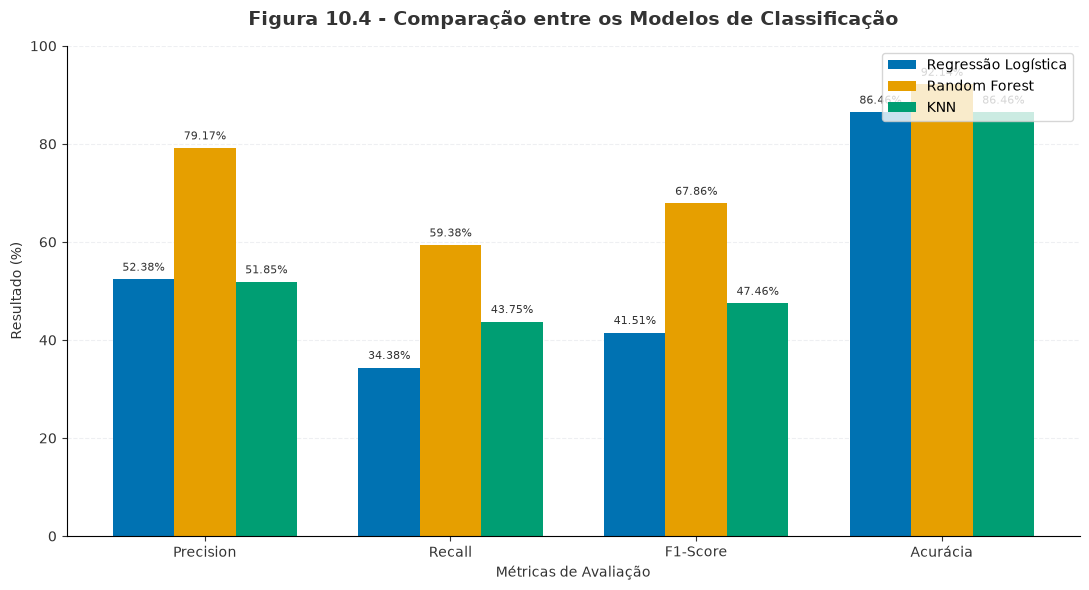

In [57]:
# Figura 10.4 - Comparação entre os Modelos de Classificação

posicoes = np.arange(
    len(comparacao_modelos)
)

largura_barras = 0.25

cor_regressao_logistica = PALETA_CATEGORICA[0]
cor_random_forest = PALETA_CATEGORICA[1]
cor_knn = PALETA_CATEGORICA[2]

figura, eixo = plt.subplots(
    figsize=(11, 6)
)

barras_regressao = eixo.bar(
    posicoes - largura_barras,
    comparacao_modelos["Regressão Logística"],
    largura_barras,
    label="Regressão Logística",
    color=cor_regressao_logistica
)

barras_random_forest = eixo.bar(
    posicoes,
    comparacao_modelos["Random Forest"],
    largura_barras,
    label="Random Forest",
    color=cor_random_forest
)

barras_knn = eixo.bar(
    posicoes + largura_barras,
    comparacao_modelos["KNN"],
    largura_barras,
    label="KNN",
    color=cor_knn
)

conjuntos_barras = [
    barras_regressao,
    barras_random_forest,
    barras_knn
]

for conjunto_barras in conjuntos_barras:

    for barra in conjunto_barras:

        valor = barra.get_height()

        eixo.text(
            barra.get_x() + barra.get_width() / 2,
            valor + 1.2,
            f"{valor:.2f}%",
            ha="center",
            va="bottom",
            fontsize=8,
            color=CORES["texto"]
        )

eixo.set_title(
    "Figura 10.4 - Comparação entre os Modelos de Classificação",
    fontsize=14,
    fontweight="bold",
    color=CORES["texto"],
    pad=15
)

eixo.set_ylabel(
    "Resultado (%)",
    color=CORES["texto"]
)

eixo.set_xlabel(
    "Métricas de Avaliação",
    color=CORES["texto"]
)

eixo.set_ylim(
    0,
    100
)

eixo.set_xticks(
    posicoes
)

eixo.set_xticklabels(
    comparacao_modelos["Métrica"]
)

eixo.tick_params(
    axis="both",
    colors=CORES["texto"]
)

eixo.grid(
    axis="y",
    linestyle="--",
    alpha=0.30,
    color=CORES["contexto"]
)

eixo.set_axisbelow(
    True
)

eixo.spines["top"].set_visible(
    False
)

eixo.spines["right"].set_visible(
    False
)

eixo.legend(
    loc="upper right",
    frameon=True
)

plt.tight_layout()

plt.show()


### 10.5 Avaliação do Gradient Boosting

O Gradient Boosting é avaliado com as mesmas métricas dos demais modelos e com matriz de confusão.


In [58]:
# 10.5 Avaliação do Gradient Boosting

resultados_gradient_boosting = avaliar_classe_alta_qualidade(
    classe_real=classe_teste,
    previsoes=previsoes_gradient_boosting,
    classe_positiva=1
)

resultados_gradient_boosting["Acurácia"] = accuracy_score(
    classe_teste,
    previsoes_gradient_boosting
)


In [59]:
# Tabela de Métricas do Gradient Boosting

ordem_metricas = [
    "Acurácia",
    "Precision",
    "Recall",
    "F1-Score"
]

tabela_metricas_gradient_boosting = pd.DataFrame({
    "Métrica": ordem_metricas,
    "Resultado (%)": [
        resultados_gradient_boosting[metrica] * 100
        for metrica in ordem_metricas
    ]
})

display(
    tabela_metricas_gradient_boosting.style
    .hide(axis="index")
    .format({
        "Resultado (%)": "{:.2f}%"
    })
    .set_caption(
        "Métricas do Gradient Boosting"
    )
)


Métrica,Resultado (%)
Acurácia,89.96%
Precision,66.67%
Recall,56.25%
F1-Score,61.02%


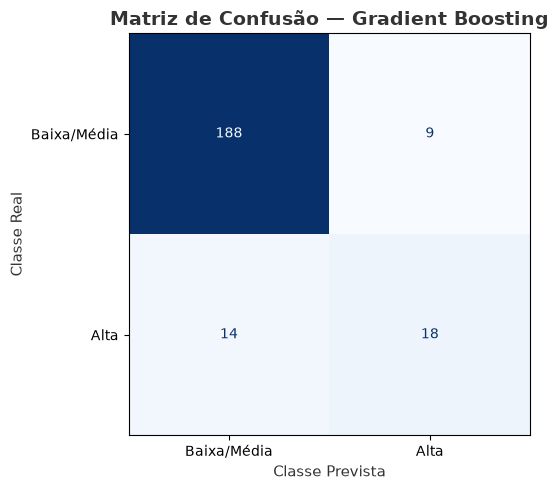

In [60]:
# Figura 10.5 - Matriz de Confusão do Gradient Boosting

figura, eixo = plt.subplots(
    figsize=(6, 5)
)

ConfusionMatrixDisplay.from_predictions(
    classe_teste,
    previsoes_gradient_boosting,
    display_labels=[
        "Baixa/Média",
        "Alta"
    ],
    cmap="Blues",
    values_format="d",
    colorbar=False,
    ax=eixo
)

eixo.set_title(
    "Matriz de Confusão — Gradient Boosting",
    fontsize=14,
    fontweight="bold",
    color=CORES["texto"]
)

eixo.set_xlabel(
    "Classe Prevista",
    fontsize=11,
    color=CORES["texto"]
)

eixo.set_ylabel(
    "Classe Real",
    fontsize=11,
    color=CORES["texto"]
)

plt.tight_layout()

salvar_grafico(
    "matriz_confusao_gradient_boosting"
)

plt.show()


#### Comparação Visual dos Modelos

O gráfico reúne as quatro métricas dos modelos em uma única visualização. Como a classe Alta Qualidade é minoritária, a comparação não se limita à Accuracy.


,Acurácia,Precision,Recall,F1-Score
Regressão Logística,86.46,52.38,34.38,41.51
Random Forest,92.14,79.17,59.38,67.86
KNN,86.46,51.85,43.75,47.46
Gradient Boosting,89.96,66.67,56.25,61.02


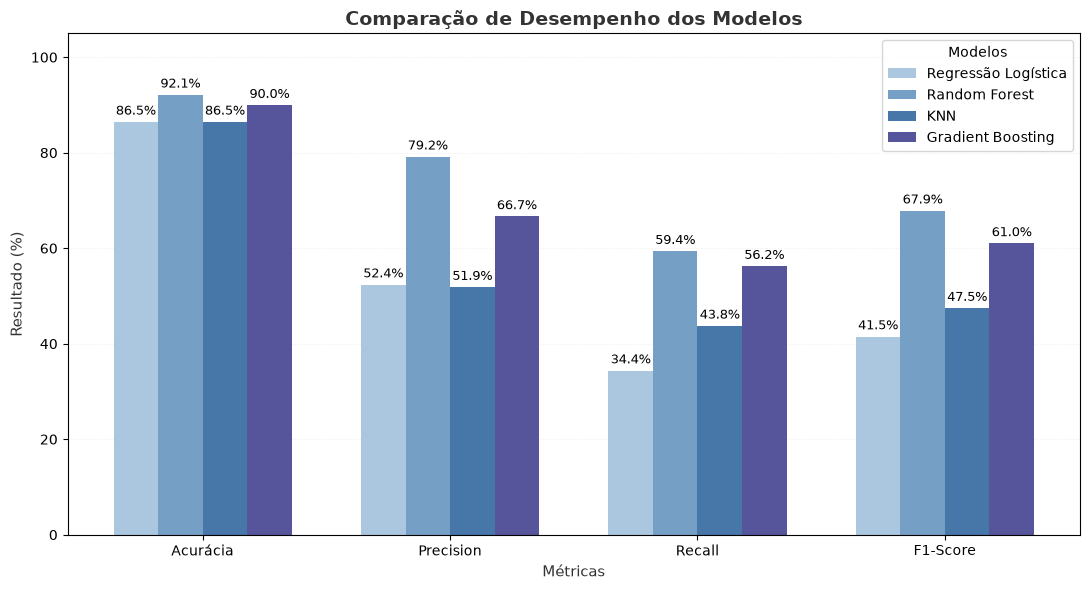

In [61]:
# Comparação Visual dos Modelos

comparacao_modelos = pd.DataFrame({
    "Regressão Logística": resultados_regressao_logistica,
    "Random Forest": resultados_random_forest,
    "KNN": resultados_knn,
    "Gradient Boosting": resultados_gradient_boosting
}).T

comparacao_modelos = comparacao_modelos[
    [
        "Acurácia",
        "Precision",
        "Recall",
        "F1-Score"
    ]
]

comparacao_modelos = comparacao_modelos * 100

display(
    comparacao_modelos.round(2)
)

metricas = comparacao_modelos.columns
modelos = comparacao_modelos.index

x = np.arange(len(metricas))
largura_barra = 0.18

figura, eixo = plt.subplots(
    figsize=(11, 6)
)

for indice, modelo in enumerate(modelos):

    deslocamento = (
        indice - (len(modelos) - 1) / 2
    ) * largura_barra

    barras = eixo.bar(
        x + deslocamento,
        comparacao_modelos.loc[modelo],
        width=largura_barra,
        label=modelo,
        color=PALETA_BARRAS[indice]
    )

    eixo.bar_label(
        barras,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

eixo.set_title(
    "Comparação de Desempenho dos Modelos",
    fontsize=14,
    fontweight="bold",
    color=CORES["texto"]
)

eixo.set_xlabel(
    "Métricas",
    fontsize=11,
    color=CORES["texto"]
)

eixo.set_ylabel(
    "Resultado (%)",
    fontsize=11,
    color=CORES["texto"]
)

eixo.set_xticks(x)
eixo.set_xticklabels(metricas)

eixo.set_ylim(
    0,
    105
)

eixo.legend(
    title="Modelos"
)

eixo.grid(
    axis="y",
    linestyle=":",
    alpha=0.20
)

eixo.set_axisbelow(True)

plt.tight_layout()

salvar_grafico(
    "comparacao_desempenho_modelos"
)

plt.show()


#### Resultado

O Gradient Boosting obteve **89,96% de Accuracy**, **66,67% de Precision**, **56,25% de Recall** e **61,02% de F1-Score**.

O modelo ficou acima da Regressão Logística e do KNN nas métricas ligadas à classe Alta Qualidade, mas abaixo do Random Forest nessa primeira divisão treino/teste.


### 10.6 Validação Cruzada dos Modelos

A comparação anterior usa uma única divisão entre treino e teste. Para verificar a estabilidade dos resultados, os quatro modelos também são avaliados com **validação cruzada estratificada em 5 folds**.

Regressão Logística e KNN usam `Pipeline`, de modo que o `StandardScaler` seja ajustado dentro de cada fold. Random Forest e Gradient Boosting usam as variáveis na escala original.


In [62]:
# 10.6 Validação Cruzada dos Modelos

from sklearn.pipeline import Pipeline

validacao_cruzada = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metricas_validacao = {
    "Accuracy": "accuracy",
    "Precision": "precision",
    "Recall": "recall",
    "F1-Score": "f1"
}

modelos_validacao = {

    "Regressão Logística": Pipeline([
        (
            "padronizacao",
            StandardScaler()
        ),
        (
            "modelo",
            LogisticRegression(
                random_state=42,
                max_iter=1000
            )
        )
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "KNN": Pipeline([
        (
            "padronizacao",
            StandardScaler()
        ),
        (
            "modelo",
            KNeighborsClassifier(
                n_neighbors=quantidade_vizinhos_knn
            )
        )
    ]),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

resultados_validacao = []

for nome_modelo, modelo in modelos_validacao.items():

    resultado = cross_validate(
        modelo,
        caracteristicas_treino,
        classe_treino,
        cv=validacao_cruzada,
        scoring=metricas_validacao
    )

    resultados_validacao.append({

        "Modelo":
            nome_modelo,

        "Accuracy Média (%)":
            resultado["test_Accuracy"].mean() * 100,

        "Precision Média (%)":
            resultado["test_Precision"].mean() * 100,

        "Recall Médio (%)":
            resultado["test_Recall"].mean() * 100,

        "F1-Score Médio (%)":
            resultado["test_F1-Score"].mean() * 100,

        "F1-Score Desvio (%)":
            resultado["test_F1-Score"].std() * 100
    })

tabela_validacao_cruzada = (
    pd.DataFrame(resultados_validacao)
    .sort_values(
        by="F1-Score Médio (%)",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    tabela_validacao_cruzada.style
    .hide(axis="index")
    .format({
        "Accuracy Média (%)": "{:.2f}%",
        "Precision Média (%)": "{:.2f}%",
        "Recall Médio (%)": "{:.2f}%",
        "F1-Score Médio (%)": "{:.2f}%",
        "F1-Score Desvio (%)": "{:.2f}%"
    })
    .set_caption(
        "Validação Cruzada dos Modelos"
    )
)


Modelo,Accuracy Média (%),Precision Média (%),Recall Médio (%),F1-Score Médio (%),F1-Score Desvio (%)
Random Forest,90.48%,74.85%,48.92%,58.83%,6.38%
Gradient Boosting,88.84%,63.45%,47.38%,54.01%,8.91%
KNN,87.20%,56.39%,40.25%,46.67%,8.41%
Regressão Logística,87.64%,61.39%,35.51%,44.48%,12.05%


#### Resultado

Na validação cruzada estratificada, o Random Forest manteve o melhor desempenho médio: **90,48% de Accuracy**, **74,85% de Precision**, **48,92% de Recall** e **58,83% de F1-Score**.

Também apresentou o menor desvio do F1 entre os folds (**6,38%**). Ainda assim, o Recall mostra que a classe Alta Qualidade continua sendo a mais difícil de identificar.


### 10.7 Modelo Baseline de Referência

O `DummyClassifier` com estratégia `most_frequent` é usado como referência simples. Ele sempre prevê a classe mais frequente e, portanto, não aprende relações entre as características físico-químicas e a qualidade.

A comparação com esse baseline ajuda a interpretar a Accuracy em uma base desbalanceada.


In [63]:
# 10.7 Modelo Baseline de Referência

from sklearn.dummy import DummyClassifier

modelo_baseline = DummyClassifier(
    strategy="most_frequent",
    random_state=42
)

modelo_baseline.fit(
    caracteristicas_treino,
    classe_treino
)

previsoes_baseline = modelo_baseline.predict(
    caracteristicas_teste
)

resultados_baseline = {
    "Acurácia": accuracy_score(
        classe_teste,
        previsoes_baseline
    ),

    "Precision": precision_score(
        classe_teste,
        previsoes_baseline,
        zero_division=0
    ),

    "Recall": recall_score(
        classe_teste,
        previsoes_baseline,
        zero_division=0
    ),

    "F1-Score": f1_score(
        classe_teste,
        previsoes_baseline,
        zero_division=0
    )
}


In [64]:
# Tabela de Métricas do Modelo Baseline

ordem_metricas = [
    "Acurácia",
    "Precision",
    "Recall",
    "F1-Score"
]

tabela_metricas_baseline = pd.DataFrame({
    "Métrica": ordem_metricas,
    "Resultado (%)": [
        resultados_baseline[metrica] * 100
        for metrica in ordem_metricas
    ]
})

display(
    tabela_metricas_baseline.style
    .hide(axis="index")
    .format({
        "Resultado (%)": "{:.2f}%"
    })
    .set_caption(
        "Métricas do Modelo Baseline"
    )
)


Métrica,Resultado (%)
Acurácia,86.03%
Precision,0.00%
Recall,0.00%
F1-Score,0.00%


#### Resultado

O baseline atingiu **86,03% de Accuracy**, mas teve **0% de Precision, Recall e F1-Score** para Alta Qualidade, pois classificou todos os registros como pertencentes à classe majoritária.

Esse resultado mostra por que a Accuracy, sozinha, é inadequada para comparar os modelos desta base.


### 10.8 Verificação de Registros Idênticos entre Treino e Teste

Também foi verificado se o teste contém combinações de características físico-químicas que aparecem no treino.

Isso não significa, por si só, que os registros sejam inválidos. Ainda assim, a repetição das mesmas combinações nos dois conjuntos pode deixar a avaliação mais favorável do que seria para combinações realmente novas.


In [65]:
# 10.8 VERIFICAÇÃO DE REGISTROS IDÊNTICOS

treino_verificacao = caracteristicas_treino.copy()
teste_verificacao = caracteristicas_teste.copy()

combinacoes_treino = set(
    treino_verificacao.itertuples(
        index=False,
        name=None
    )
)

registro_presente_treino = teste_verificacao.apply(
    lambda linha: tuple(linha) in combinacoes_treino,
    axis=1
)

quantidade_teste = len(
    teste_verificacao
)

quantidade_repetidos = (
    registro_presente_treino.sum()
)

percentual_repetidos = (
    quantidade_repetidos
    / quantidade_teste
) * 100

resumo_registros_identicos = pd.DataFrame({
    "Indicador": [
        "Registros no conjunto de teste",
        "Registros do teste também presentes no treino",
        "Registros exclusivos do conjunto de teste"
    ],
    "Quantidade": [
        quantidade_teste,
        quantidade_repetidos,
        quantidade_teste - quantidade_repetidos
    ],
    "Percentual (%)": [
        100,
        percentual_repetidos,
        100 - percentual_repetidos
    ]
})

display(
    resumo_registros_identicos.style
    .hide(axis="index")
    .format({
        "Percentual (%)": "{:.2f}%"
    })
    .set_caption(
        "Verificação de Registros Idênticos entre Treino e Teste"
    )
)


Indicador,Quantidade,Percentual (%)
Registros no conjunto de teste,229,100.00%
Registros do teste também presentes no treino,34,14.85%
Registros exclusivos do conjunto de teste,195,85.15%


In [66]:
# Distribuição dos Registros Idênticos Por Classe

analise_repetidos_classe = pd.DataFrame({
    "Classe": classe_teste,
    "Presente no Treino": registro_presente_treino
})

repetidos_por_classe = (
    analise_repetidos_classe
    .groupby("Classe")["Presente no Treino"]
    .agg([
        "sum",
        "count"
    ])
    .reset_index()
)

repetidos_por_classe["Percentual (%)"] = (
    repetidos_por_classe["sum"]
    / repetidos_por_classe["count"]
) * 100

repetidos_por_classe = repetidos_por_classe.rename(
    columns={
        "sum": "Registros presentes no treino",
        "count": "Total da classe"
    }
)

repetidos_por_classe["Classe"] = (
    repetidos_por_classe["Classe"]
    .map({
        0: "Baixa/Média Qualidade",
        1: "Alta Qualidade"
    })
)

display(
    repetidos_por_classe.style
    .hide(axis="index")
    .format({
        "Percentual (%)": "{:.2f}%"
    })
    .set_caption(
        "Registros Idênticos por Classe"
    )
)


Classe,Registros presentes no treino,Total da classe,Percentual (%)
Baixa/Média Qualidade,26,197,13.20%
Alta Qualidade,8,32,25.00%


#### Resultado

Dos **229 registros** do conjunto de teste, **34 (14,85%)** têm uma combinação de características também presente no treino.

A ocorrência é de **13,20%** na classe Baixa/Média e de **25,00%** na classe Alta. Como a repetição é proporcionalmente maior na classe minoritária, foi feita uma validação adicional que mantém combinações idênticas no mesmo grupo.


### 10.9 Validação Cruzada Estratificada por Grupos

Como foram encontradas combinações idênticas entre treino e teste, foi feita uma validação adicional com `StratifiedGroupKFold`.

Registros com a mesma combinação de características permanecem no mesmo grupo. Assim, uma combinação usada no treino de um fold não aparece na validação desse mesmo fold.


In [67]:
# 10.9 Validação Cruzada Estratificada Por Grupos

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline

grupos = (
    caracteristicas_vinho
    .astype(str)
    .agg("|".join, axis=1)
)

validacao_grupos = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metricas_validacao_grupos = {
    "Accuracy": "accuracy",
    "Precision": "precision",
    "Recall": "recall",
    "F1-Score": "f1"
}

modelos_validacao_grupos = {

    "Regressão Logística": Pipeline([
        (
            "padronizacao",
            StandardScaler()
        ),
        (
            "modelo",
            LogisticRegression(
                random_state=42,
                max_iter=1000
            )
        )
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "KNN": Pipeline([
        (
            "padronizacao",
            StandardScaler()
        ),
        (
            "modelo",
            KNeighborsClassifier(
                n_neighbors=quantidade_vizinhos_knn
            )
        )
    ]),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

resultados_validacao_grupos = []

for nome_modelo, modelo in modelos_validacao_grupos.items():

    resultado = cross_validate(
        modelo,
        caracteristicas_vinho,
        classe_qualidade,
        groups=grupos,
        cv=validacao_grupos,
        scoring=metricas_validacao_grupos
    )

    resultados_validacao_grupos.append({

        "Modelo":
            nome_modelo,

        "Accuracy Média (%)":
            resultado["test_Accuracy"].mean() * 100,

        "Precision Média (%)":
            resultado["test_Precision"].mean() * 100,

        "Recall Médio (%)":
            resultado["test_Recall"].mean() * 100,

        "F1-Score Médio (%)":
            resultado["test_F1-Score"].mean() * 100,

        "F1-Score Desvio (%)":
            resultado["test_F1-Score"].std() * 100
    })

tabela_validacao_grupos = (
    pd.DataFrame(resultados_validacao_grupos)
    .sort_values(
        by="F1-Score Médio (%)",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    tabela_validacao_grupos.style
    .hide(axis="index")
    .format({
        "Accuracy Média (%)": "{:.2f}%",
        "Precision Média (%)": "{:.2f}%",
        "Recall Médio (%)": "{:.2f}%",
        "F1-Score Médio (%)": "{:.2f}%",
        "F1-Score Desvio (%)": "{:.2f}%"
    })
    .set_caption(
        "Validação Cruzada Estratificada por Grupos"
    )
)


Modelo,Accuracy Média (%),Precision Média (%),Recall Médio (%),F1-Score Médio (%),F1-Score Desvio (%)
Random Forest,88.63%,65.63%,35.87%,45.63%,12.15%
Gradient Boosting,87.05%,53.97%,38.99%,44.97%,10.20%
Regressão Logística,87.49%,57.71%,35.26%,43.15%,9.32%
KNN,85.39%,46.78%,38.45%,41.91%,7.69%


#### Resultado

Quando combinações idênticas foram mantidas no mesmo grupo, as métricas diminuíram. O Random Forest ainda teve o maior F1 médio (**45,63%**), mas ficou muito próximo do Gradient Boosting (**44,97%**).

O Gradient Boosting apresentou o maior Recall (**38,99%**). A diferença pequena entre os dois modelos justificou levar ambos para a etapa de otimização.


## 11. Otimização dos Modelos Candidatos

Random Forest e Gradient Boosting apresentaram os melhores resultados nas avaliações anteriores e seguiram para ajuste de hiperparâmetros.

A busca usa a validação estratificada por grupos e o **F1-Score da classe Alta Qualidade** como principal critério de seleção.


### 11.1 Otimização do Random Forest

O `GridSearchCV` testa diferentes combinações de hiperparâmetros do Random Forest, incluindo número de árvores, profundidade e quantidade mínima de amostras para divisões e folhas.

A melhor configuração é escolhida pelo F1-Score na validação por grupos.


In [68]:
# 11.1 Otimização do Random Forest

from sklearn.model_selection import GridSearchCV

modelo_rf_otimizacao = RandomForestClassifier(
    random_state=42
)

parametros_rf = {

    "n_estimators": [
        100,
        200,
        300
    ],

    "max_depth": [
        None,
        5,
        10
    ],

    "min_samples_split": [
        2,
        5,
        10
    ],

    "min_samples_leaf": [
        1,
        2,
        4
    ],

    "max_features": [
        "sqrt",
        "log2"
    ]
}

grid_search_rf = GridSearchCV(
    estimator=modelo_rf_otimizacao,
    param_grid=parametros_rf,
    scoring="f1",
    cv=validacao_grupos,
    n_jobs=-1,
    return_train_score=True
)

grid_search_rf.fit(
    caracteristicas_vinho,
    classe_qualidade,
    groups=grupos
)

print(
    "Melhores hiperparâmetros:"
)

print(
    grid_search_rf.best_params_
)

print(
    "\nMelhor F1-Score médio:"
)

print(
    f"{grid_search_rf.best_score_ * 100:.2f}%"
)


Melhores hiperparâmetros:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Melhor F1-Score médio:
45.63%


#### Resultado

A melhor configuração encontrada para o Random Forest foi:

`n_estimators=100`, `max_depth=None`, `max_features="sqrt"`, `min_samples_leaf=1` e `min_samples_split=5`.

O F1 médio permaneceu em **45,63%**, sem ganho em relação ao modelo anterior. Dentro da grade testada, a otimização não melhorou o desempenho.


### 11.2 Otimização do Gradient Boosting

O Gradient Boosting também é otimizado com `GridSearchCV`. A busca avalia número de estimadores, taxa de aprendizado, profundidade e parâmetros mínimos de divisão e folha, usando o mesmo critério aplicado ao Random Forest.


In [69]:
# 11.2 Otimização do Gradient Boosting

modelo_gb_otimizacao = GradientBoostingClassifier(
    random_state=42
)

parametros_gb = {

    "n_estimators": [
        50,
        100,
        200
    ],

    "learning_rate": [
        0.05,
        0.10,
        0.20
    ],

    "max_depth": [
        1,
        2,
        3
    ],

    "min_samples_split": [
        2,
        5
    ],

    "min_samples_leaf": [
        1,
        2
    ]
}

grid_search_gb = GridSearchCV(
    estimator=modelo_gb_otimizacao,
    param_grid=parametros_gb,
    scoring="f1",
    cv=validacao_grupos,
    n_jobs=-1,
    return_train_score=True
)

grid_search_gb.fit(
    caracteristicas_vinho,
    classe_qualidade,
    groups=grupos
)

print(
    "Melhores hiperparâmetros:"
)

print(
    grid_search_gb.best_params_
)

print(
    "\nMelhor F1-Score médio:"
)

print(
    f"{grid_search_gb.best_score_ * 100:.2f}%"
)


Melhores hiperparâmetros:
{'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Melhor F1-Score médio:
49.97%


#### Resultado

A melhor configuração do Gradient Boosting foi:

`learning_rate=0.05`, `max_depth=3`, `min_samples_leaf=1`, `min_samples_split=2` e `n_estimators=200`.

O F1 médio passou de **44,97% para 49,97%**, um ganho de **5,00 pontos percentuais** na validação por grupos.


### 11.3 Avaliação e Comparação dos Modelos Otimizados

As melhores configurações de Random Forest e Gradient Boosting são avaliadas novamente com a validação estratificada por grupos.

Além do F1-Score, são comparados Accuracy, Precision, Recall e a variação do F1 entre os folds.


In [70]:
# 11.3 Avaliação e Comparação dos Modelos Otimizados

modelo_rf_otimizado = grid_search_rf.best_estimator_

modelo_gb_otimizado = grid_search_gb.best_estimator_

modelos_otimizados = {
    "Random Forest Otimizado":
        modelo_rf_otimizado,

    "Gradient Boosting Otimizado":
        modelo_gb_otimizado
}

resultados_modelos_otimizados = []

for nome_modelo, modelo in modelos_otimizados.items():

    resultado = cross_validate(
        modelo,
        caracteristicas_vinho,
        classe_qualidade,
        groups=grupos,
        cv=validacao_grupos,
        scoring=metricas_validacao_grupos
    )

    resultados_modelos_otimizados.append({

        "Modelo":
            nome_modelo,

        "Accuracy Média (%)":
            resultado["test_Accuracy"].mean() * 100,

        "Precision Média (%)":
            resultado["test_Precision"].mean() * 100,

        "Recall Médio (%)":
            resultado["test_Recall"].mean() * 100,

        "F1-Score Médio (%)":
            resultado["test_F1-Score"].mean() * 100,

        "F1-Score Desvio (%)":
            resultado["test_F1-Score"].std() * 100
    })

tabela_modelos_otimizados = (
    pd.DataFrame(
        resultados_modelos_otimizados
    )
    .sort_values(
        by="F1-Score Médio (%)",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    tabela_modelos_otimizados.style
    .hide(axis="index")
    .format({
        "Accuracy Média (%)": "{:.2f}%",
        "Precision Média (%)": "{:.2f}%",
        "Recall Médio (%)": "{:.2f}%",
        "F1-Score Médio (%)": "{:.2f}%",
        "F1-Score Desvio (%)": "{:.2f}%"
    })
    .set_caption(
        "Comparação dos Modelos Otimizados"
    )
)


Modelo,Accuracy Média (%),Precision Média (%),Recall Médio (%),F1-Score Médio (%),F1-Score Desvio (%)
Gradient Boosting Otimizado,88.02%,58.84%,44.05%,49.97%,9.24%
Random Forest Otimizado,88.28%,62.20%,37.14%,45.63%,12.68%


#### Resultado

O Random Forest otimizado teve Accuracy e Precision ligeiramente maiores, mas o Gradient Boosting otimizado apresentou **Recall de 44,05%** e **F1-Score de 49,97%**, além de menor variação do F1 entre os folds.

Como o objetivo exige atenção à classe Alta Qualidade, o Gradient Boosting foi escolhido para a avaliação final.


### 11.4 Avaliação Final do Modelo Selecionado

O Gradient Boosting otimizado foi o modelo escolhido para a avaliação final. As previsões são geradas de forma *out-of-fold* com separação por grupos, para que cada observação seja prevista por um modelo que não foi treinado com aquele grupo.

Como os hiperparâmetros foram selecionados usando a mesma base, essa etapa é tratada como avaliação complementar, e não como teste externo independente.


In [71]:
# 11.4 Avaliação Final do Modelo Selecionado

from sklearn.model_selection import cross_val_predict

modelo_final = grid_search_gb.best_estimator_

previsoes_finais = cross_val_predict(
    modelo_final,
    caracteristicas_vinho,
    classe_qualidade,
    groups=grupos,
    cv=validacao_grupos,
    method="predict",
    n_jobs=-1
)

resultados_modelo_final = {

    "Acurácia": accuracy_score(
        classe_qualidade,
        previsoes_finais
    ),

    "Precision": precision_score(
        classe_qualidade,
        previsoes_finais,
        zero_division=0
    ),

    "Recall": recall_score(
        classe_qualidade,
        previsoes_finais,
        zero_division=0
    ),

    "F1-Score": f1_score(
        classe_qualidade,
        previsoes_finais,
        zero_division=0
    )
}

ordem_metricas = [
    "Acurácia",
    "Precision",
    "Recall",
    "F1-Score"
]

tabela_modelo_final = pd.DataFrame({

    "Métrica":
        ordem_metricas,

    "Resultado (%)": [
        resultados_modelo_final[metrica] * 100
        for metrica in ordem_metricas
    ]
})

display(
    tabela_modelo_final.style
    .hide(axis="index")
    .format({
        "Resultado (%)": "{:.2f}%"
    })
    .set_caption(
        "Avaliação do Gradient Boosting Selecionado"
    )
)


Métrica,Resultado (%)
Acurácia,88.01%
Precision,59.32%
Recall,44.03%
F1-Score,50.54%


#### Resultado

Nas previsões *out-of-fold*, o Gradient Boosting otimizado apresentou **88,01% de Accuracy**, **59,32% de Precision**, **44,03% de Recall** e **50,54% de F1-Score**.

O Recall indica que mais da metade dos vinhos de Alta Qualidade ainda não é identificada corretamente. Esse continua sendo o principal limite do modelo.


## 12. Interpretação do Modelo

Depois da avaliação, o foco passa a ser entender quais características têm maior peso nas decisões do Gradient Boosting selecionado.


### 12.1 Importância das Variáveis

A importância relativa das variáveis é obtida pelo atributo `feature_importances_` do Gradient Boosting.

O valor indica quanto cada característica contribuiu para as divisões das árvores. Ele não informa direção do efeito e não deve ser interpretado como causalidade.


In [72]:
# 12.1 Importância das Variáveis

modelo_interpretacao = grid_search_gb.best_estimator_

modelo_interpretacao.fit(
    caracteristicas_vinho,
    classe_qualidade
)

importancias_variaveis = (
    modelo_interpretacao.feature_importances_
)

tabela_importancias = pd.DataFrame({

    "Variável Original":
        caracteristicas_vinho.columns,

    "Importância":
        importancias_variaveis

})

tabela_importancias["Variável"] = (
    tabela_importancias["Variável Original"]
    .map(
        lambda coluna:
        NOMES_VARIAVEIS.get(coluna, coluna)
    )
)

tabela_importancias["Importância (%)"] = (
    tabela_importancias["Importância"] * 100
)

tabela_importancias = (
    tabela_importancias
    .sort_values(
        by="Importância (%)",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    tabela_importancias[
        [
            "Variável",
            "Importância (%)"
        ]
    ]
    .style
    .hide(axis="index")
    .format({
        "Importância (%)": "{:.2f}%"
    })
    .set_caption(
        "Importância das Variáveis — Gradient Boosting"
    )
)


Variável,Importância (%)
Teor alcoólico,28.79%
Acidez volátil,15.55%
Sulfatos,13.31%
Dióxido de enxofre total,6.84%
Acidez fixa,6.43%
Ácido cítrico,6.22%
Dióxido de enxofre livre,5.48%
Açúcar residual,4.45%
Densidade,4.39%
pH,4.31%


#### Resultado

O **Teor alcoólico** teve a maior importância relativa no Gradient Boosting (**28,79%**), seguido por **Acidez volátil (15,55%)** e **Sulfatos (13,31%)**. Juntas, as três variáveis concentram **57,65%** da importância do modelo.

Esses valores mostram contribuição para as decisões das árvores, mas não indicam causalidade nem a direção do efeito.


### 12.2 Relação entre as Principais Variáveis e a Classe Alvo

As três variáveis mais importantes para o modelo — **Teor alcoólico, Acidez volátil e Sulfatos** — são comparadas entre as duas classes.

A ideia é verificar se as diferenças observadas na EDA também aparecem entre as características mais usadas pelo modelo.


In [73]:
# 12.2 RELAÇÃO ENTRE AS PRINCIPAIS VARIÁVEIS

principais_variaveis = [
    "alcohol",
    "volatile acidity",
    "sulphates"
]

resultado_principais_variaveis = []

for coluna in principais_variaveis:

    valores_baixa_media = df.loc[
        df["quality_label"] == 0,
        coluna
    ]

    valores_alta = df.loc[
        df["quality_label"] == 1,
        coluna
    ]

    # Armazena média e mediana de cada grupo.
    resultado_principais_variaveis.append({

        "Variável":
            NOMES_VARIAVEIS.get(coluna, coluna),

        "Média — Baixa/Média":
            valores_baixa_media.mean(),

        "Média — Alta":
            valores_alta.mean(),

        "Mediana — Baixa/Média":
            valores_baixa_media.median(),

        "Mediana — Alta":
            valores_alta.median()
    })

tabela_principais_variaveis = pd.DataFrame(
    resultado_principais_variaveis
)

display(
    tabela_principais_variaveis.style
    .hide(axis="index")
    .format({
        "Média — Baixa/Média": "{:.3f}",
        "Média — Alta": "{:.3f}",
        "Mediana — Baixa/Média": "{:.3f}",
        "Mediana — Alta": "{:.3f}"
    })
    .set_caption(
        "Principais Variáveis por Classe de Qualidade"
    )
)


Variável,Média — Baixa/Média,Média — Alta,Mediana — Baixa/Média,Mediana — Alta
Teor alcoólico,10.267,11.528,10.000,11.600
Acidez volátil,0.553,0.395,0.550,0.360
Sulfatos,0.643,0.746,0.600,0.740


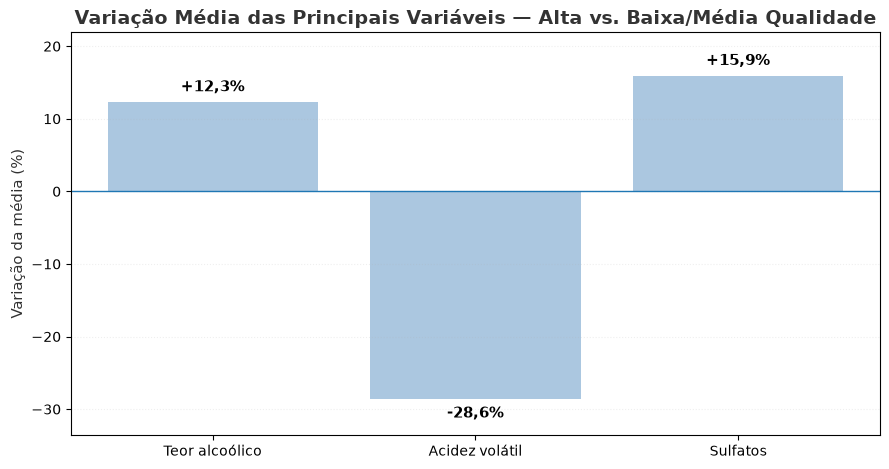

In [74]:
# Variação das Principais Variáveis Entre As Classes

tabela_principais_variaveis["Variação Média (%)"] = (
    (
        tabela_principais_variaveis["Média — Alta"]
        -
        tabela_principais_variaveis["Média — Baixa/Média"]
    )
    /
    tabela_principais_variaveis["Média — Baixa/Média"]
) * 100


# Dados do gráfico
variaveis = tabela_principais_variaveis["Variável"]
valores = tabela_principais_variaveis["Variação Média (%)"]


# Criação da figura
fig, ax = plt.subplots(
    figsize=(9, 5)
)


# Barras
barras = ax.bar(
    variaveis,
    valores,
    color=PALETA_BARRAS[0]
)


# Linha de referência em zero
ax.axhline(
    y=0,
    linewidth=1
)


# --------------------------------------------------
# AJUSTE DO ESPAÇO DO EIXO Y
# Evita que os rótulos encostem no título ou na borda
# --------------------------------------------------

limite_superior = max(valores) + 6
limite_inferior = min(valores) - 5

ax.set_ylim(
    limite_inferior,
    limite_superior
)


# --------------------------------------------------
# RÓTULOS
# --------------------------------------------------

for barra, valor in zip(barras, valores):

    rotulo = f"{valor:+.1f}%".replace(".", ",")

    # Centro exato da barra
    x = barra.get_x() + barra.get_width() / 2

    if valor >= 0:

        ax.text(
            x,
            valor + 1.0,
            rotulo,
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

    else:

        ax.text(
            x,
            valor - 1.0,
            rotulo,
            ha="center",
            va="top",
            fontsize=11,
            fontweight="bold"
        )


# Formatação padrão do projeto
grafico_format(
    titulo=(
        "Variação Média das Principais Variáveis — "
        "Alta vs. Baixa/Média Qualidade"
    ),
    xlabel="",
    ylabel="Variação da média (%)"
)


# Mais espaço para o título
plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)


# Salvar
salvar_grafico(
    "variacao_principais_variaveis_classe"
)


plt.show()

#### Resultado

As três variáveis mais importantes também apresentam diferenças entre as classes. Na classe Alta Qualidade, a média do **Teor alcoólico** é cerca de **12,3% maior** e a de **Sulfatos**, aproximadamente **16,0% maior**. A **Acidez volátil** é cerca de **28,6% menor**.

O padrão é coerente com a EDA e com a importância atribuída pelo modelo, mas continua sendo uma associação observada na amostra.


### 12.3 Teste Estatístico das Principais Variáveis

A comparação anterior mostrou diferenças de média e mediana entre as classes, mas, isoladamente, essa descrição não permite avaliar se as diferenças observadas são consistentes na amostra.

Nesta etapa é aplicado o **teste de Mann–Whitney U** às três variáveis de maior importância no modelo — **Teor alcoólico, Acidez volátil e Sulfatos**. O teste é não paramétrico e compara as distribuições de dois grupos independentes sem exigir normalidade.

Será adotado **nível de significância de 5% (α = 0,05)**. Um valor de `p < 0,05` indica evidência estatística de diferença entre as classes para a variável analisada. O resultado não demonstra causalidade.

In [75]:
# 12.3 Teste Estatístico das Principais Variáveis

from scipy.stats import mannwhitneyu

resultado_testes = []

for coluna in principais_variaveis:

    valores_baixa_media = df.loc[df["quality_label"] == 0, coluna].dropna()
    valores_alta = df.loc[df["quality_label"] == 1, coluna].dropna()

    estatistica_u, valor_p = mannwhitneyu(
        valores_alta,
        valores_baixa_media,
        alternative="two-sided"
    )

    resultado_testes.append({
        "Variável": NOMES_VARIAVEIS.get(coluna, coluna),
        "Estatística U": estatistica_u,
        "p-valor": valor_p,
        "Diferença estatística (5%)": "Sim" if valor_p < 0.05 else "Não"
    })

tabela_testes = pd.DataFrame(resultado_testes)

display(
    tabela_testes.style
    .hide(axis="index")
    .format({
        "Estatística U": "{:.2f}",
        "p-valor": "{:.6f}"
    })
    .set_caption("Teste de Mann–Whitney U — Principais Variáveis")
)

Variável,Estatística U,p-valor,Diferença estatística (5%)
Teor alcoólico,128153.00,0.000000,Sim
Acidez volátil,35688.00,0.000000,Sim
Sulfatos,116195.00,0.000000,Sim


#### Resultado

A tabela acima deve ser interpretada em conjunto com as diferenças de média e mediana já observadas. Para cada variável, um **p-valor inferior a 0,05** fornece evidência estatística de que as distribuições das classes Alta Qualidade e Baixa/Média Qualidade diferem na amostra.

Entretanto, significância estatística não informa a **magnitude** da diferença. Por isso, a próxima etapa calcula o tamanho de efeito. Também é importante destacar que uma diferença estatisticamente significativa representa **associação**, e não uma relação de causa e efeito.

### 12.4 Tamanho de Efeito das Diferenças entre as Classes

Além do teste de significância, é importante avaliar o tamanho da diferença entre as classes. Para isso, é calculada a **correlação bisserial por postos**, derivada da estatística U de Mann–Whitney.

O valor varia de **−1 a +1**. O sinal indica a direção da diferença considerando Alta Qualidade em relação a Baixa/Média Qualidade, enquanto o valor absoluto indica sua magnitude. Como referência descritiva neste notebook: **< 0,10 desprezível; 0,10–0,29 pequeno; 0,30–0,49 moderado; ≥ 0,50 grande**.

Essa classificação serve apenas para facilitar a leitura do efeito observado e não transforma a associação em causalidade.

In [76]:
# 12.4 Tamanho de Efeito das Diferenças Entre As Classes

def classificar_tamanho_efeito(valor):
    magnitude = abs(valor)
    if magnitude < 0.10:
        return "Desprezível"
    elif magnitude < 0.30:
        return "Pequeno"
    elif magnitude < 0.50:
        return "Moderado"
    return "Grande"

resultado_efeito = []

for coluna in principais_variaveis:

    valores_alta = df.loc[df["quality_label"] == 1, coluna].dropna()
    valores_baixa_media = df.loc[df["quality_label"] == 0, coluna].dropna()

    estatistica_u, _ = mannwhitneyu(
        valores_alta,
        valores_baixa_media,
        alternative="two-sided"
    )

    n_alta = len(valores_alta)
    n_baixa_media = len(valores_baixa_media)

    efeito = (2 * estatistica_u) / (n_alta * n_baixa_media) - 1

    resultado_efeito.append({
        "Variável": NOMES_VARIAVEIS.get(coluna, coluna),
        "Tamanho de efeito": efeito,
        "Magnitude": classificar_tamanho_efeito(efeito),
        "Direção": "Maior em Alta" if efeito > 0 else "Menor em Alta" if efeito < 0 else "Sem direção"
    })

tabela_efeito = pd.DataFrame(resultado_efeito)

display(
    tabela_efeito.style
    .hide(axis="index")
    .format({"Tamanho de efeito": "{:.3f}"})
    .set_caption("Tamanho de Efeito — Alta vs. Baixa/Média Qualidade")
)

Variável,Tamanho de efeito,Magnitude,Direção
Teor alcoólico,0.638,Grande,Maior em Alta
Acidez volátil,-0.544,Grande,Menor em Alta
Sulfatos,0.485,Moderado,Maior em Alta


#### Resultado

O tamanho de efeito complementa o p-valor ao mostrar **quanto as distribuições das duas classes se diferenciam**. Valores absolutos maiores representam separação mais acentuada entre Alta Qualidade e Baixa/Média Qualidade.

Na interpretação final, devem receber maior atenção as variáveis que reúnam evidências convergentes: **alta importância no modelo, diferença estatística entre as classes e tamanho de efeito relevante**. Essa combinação fortalece a identificação de características associadas à qualidade, mas ainda não permite afirmar que modificar essas características causará aumento da qualidade.

### 12.5 Faixas Observadas nas Principais Variáveis

Para aproximar os resultados de uma discussão sobre possíveis implicações para o processo de produção, são examinados os **quartis das três principais variáveis em cada classe**.

O intervalo entre o primeiro e o terceiro quartil (Q1–Q3) representa a faixa central de 50% dos registros de cada grupo. O objetivo não é definir valores ideais de fabricação, mas verificar **em quais faixas os vinhos de cada classe se concentram nesta amostra**.

In [77]:
# 12.5 Faixas Observadas nas Principais Variáveis

resultado_faixas = []

for coluna in principais_variaveis:
    for classe, nome_classe in [(0, "Baixa/Média"), (1, "Alta")]:

        valores = df.loc[df["quality_label"] == classe, coluna].dropna()

        resultado_faixas.append({
            "Variável": NOMES_VARIAVEIS.get(coluna, coluna),
            "Classe": nome_classe,
            "Q1 (25%)": valores.quantile(0.25),
            "Mediana": valores.median(),
            "Q3 (75%)": valores.quantile(0.75),
            "Mínimo": valores.min(),
            "Máximo": valores.max()
        })

tabela_faixas = pd.DataFrame(resultado_faixas)

display(
    tabela_faixas.style
    .hide(axis="index")
    .format({
        "Q1 (25%)": "{:.3f}",
        "Mediana": "{:.3f}",
        "Q3 (75%)": "{:.3f}",
        "Mínimo": "{:.3f}",
        "Máximo": "{:.3f}"
    })
    .set_caption("Faixas Observadas das Principais Variáveis por Classe")
)

Variável,Classe,Q1 (25%),Mediana,Q3 (75%),Mínimo,Máximo
Teor alcoólico,Baixa/Média,9.500,10.000,10.900,8.400,14.900
Teor alcoólico,Alta,10.800,11.600,12.250,9.200,14.000
Acidez volátil,Baixa/Média,0.430,0.550,0.660,0.160,1.580
Acidez volátil,Alta,0.300,0.360,0.480,0.120,0.850
Sulfatos,Baixa/Média,0.540,0.600,0.692,0.330,2.000
Sulfatos,Alta,0.660,0.740,0.835,0.390,1.360


#### Resultado

As faixas observadas reforçam a separação entre as classes identificada nas análises anteriores.

Para **Teor alcoólico**, a metade central dos vinhos de Alta Qualidade está entre **10,80 e 12,25**, com mediana de **11,60**. Na classe Baixa/Média, 50% dos registros estão entre **9,50 e 10,90**, com mediana de **10,00**. A distribuição dos vinhos de Alta Qualidade, portanto, está deslocada para valores mais elevados.

Na **Acidez volátil**, o comportamento é inverso. Os vinhos de Alta Qualidade apresentam faixa central entre **0,30 e 0,48**, com mediana de **0,36**, enquanto a classe Baixa/Média apresenta valores entre **0,43 e 0,66**, com mediana de **0,55**. Os vinhos de Alta Qualidade concentram-se, portanto, em níveis menores de acidez volátil.

Para **Sulfatos**, a faixa central da Alta Qualidade está entre **0,66 e 0,835**, com mediana de **0,74**. Na classe Baixa/Média, a faixa é de **0,54 a 0,692**, com mediana de **0,60**.

Apesar do deslocamento das distribuições, existe sobreposição entre as classes. Por esse motivo, essas faixas não representam pontos de corte para classificação nem valores ideais de produção. Elas descrevem apenas o comportamento observado na amostra analisada.


## 13. Interpretação dos Resultados

### 13.1 Variáveis com maior influência na qualidade

A interpretação foi construída a partir da combinação de diferentes evidências do projeto: **importância das variáveis no Gradient Boosting, comparação entre as classes, teste de Mann–Whitney U, tamanho de efeito e distribuição dos valores por quartis**. A leitura conjunta reduz a dependência de uma única métrica e permite identificar quais características apresentam evidências mais consistentes de associação com a qualidade.

Entre as variáveis avaliadas, **Teor alcoólico, Acidez volátil e Sulfatos** foram as que apresentaram maior importância no Gradient Boosting, com **28,79%**, **15,55%** e **13,31%**, respectivamente. Juntas, representam **57,65% da importância atribuída pelo modelo**.

O teste de Mann–Whitney U mostrou **diferença estatisticamente significativa (p < 0,05)** entre os vinhos de Alta Qualidade e Baixa/Média Qualidade para as três variáveis. O tamanho de efeito complementa esse resultado ao mostrar que a magnitude da diferença é **grande para Teor alcoólico (0,638)** e **Acidez volátil (-0,544)** e **moderada para Sulfatos (0,485)**.

A direção dos efeitos também é relevante. Os vinhos de Alta Qualidade apresentam **Teor alcoólico mais elevado**, **Acidez volátil mais baixa** e **Sulfatos mais elevados**. A análise dos quartis confirma esse padrão:

| Variável | Baixa/Média — Q1 a Q3 | Alta — Q1 a Q3 | Mediana Baixa/Média | Mediana Alta |
|---|---:|---:|---:|---:|
| Teor alcoólico | 9,50 – 10,90 | 10,80 – 12,25 | 10,00 | 11,60 |
| Acidez volátil | 0,43 – 0,66 | 0,30 – 0,48 | 0,55 | 0,36 |
| Sulfatos | 0,54 – 0,692 | 0,66 – 0,835 | 0,60 | 0,74 |

Considerando o conjunto das evidências, **Teor alcoólico e Acidez volátil são as variáveis que apresentam maior capacidade de diferenciação entre as duas classes dentre as três características analisadas**. O Teor alcoólico possui a maior importância no modelo e o maior tamanho de efeito. A Acidez volátil apresenta a segunda maior importância e também um efeito de grande magnitude, em direção inversa. Os Sulfatos permanecem relevantes, porém apresentam menor importância no modelo e tamanho de efeito moderado.

Esses resultados devem ser interpretados como **associações observadas na base analisada**. A importância atribuída pelo modelo e as diferenças estatísticas não demonstram que essas variáveis, isoladamente, sejam responsáveis pela qualidade do vinho.

### 13.2 Possíveis implicações para o processo de produção

Sob a perspectiva de analytics, os resultados permitem priorizar variáveis para **monitoramento, controle e investigação**. Teor alcoólico e Acidez volátil concentram as evidências mais fortes e, por isso, podem receber maior atenção em análises relacionadas à qualidade. Os Sulfatos também podem ser acompanhados como variável relevante, embora apresentem menor poder de diferenciação entre as classes quando comparados às duas primeiras características.

As faixas observadas nos vinhos de Alta Qualidade — **10,80 a 12,25 para Teor alcoólico, 0,30 a 0,48 para Acidez volátil e 0,66 a 0,835 para Sulfatos**, considerando Q1–Q3 — podem ser utilizadas como **referência analítica para investigação de padrões**, comparação de lotes e formulação de hipóteses para estudos posteriores.

Esses intervalos, entretanto, **não devem ser tratados como especificações ou metas de produção**. Há sobreposição entre as distribuições das classes, e a base utilizada é observacional. Portanto, os resultados não permitem afirmar que aumentar o Teor alcoólico ou os Sulfatos, ou reduzir a Acidez volátil, causará aumento na qualidade.

A principal implicação prática é utilizar os achados como direcionadores de análise: acompanhar as variáveis que mais diferenciam os grupos, investigar desvios em relação aos padrões observados e avaliar sua relação com outros fatores do processo produtivo. Para transformar essas associações em recomendações de produção, seriam necessários dados das etapas do processo e estudos capazes de avaliar relações de causa e efeito.

### 13.3 Síntese

Os resultados indicam uma hierarquia clara entre as principais características analisadas:

1. **Teor alcoólico** — maior importância no modelo e maior tamanho de efeito, com valores mais elevados nos vinhos de Alta Qualidade.
2. **Acidez volátil** — segunda maior importância e tamanho de efeito grande, com valores mais baixos nos vinhos de Alta Qualidade.
3. **Sulfatos** — terceira maior importância e tamanho de efeito moderado, com valores mais elevados nos vinhos de Alta Qualidade.

A convergência entre modelo, testes estatísticos e análise das distribuições sustenta a utilização dessas variáveis como **indicadores relevantes para acompanhamento da qualidade**, mantendo-se a distinção entre associação estatística e causalidade.
